# Structural Robustness and Link-Prediction Stability in the Global Air-Transport Network
## A Centrality-Aware, Spectral, and Graph-Attention Study of Targeted Airport Removal

**Research-grade computational notebook: expanded EDA, graph diagnostics, perturbation methodology, and GNN robustness analysis**

---

### Abstract

Air-transport networks concentrate connectivity in a small set of hub airports, creating efficiency under normal operation and potential vulnerability under disruption. This study develops a reproducible framework for evaluating how node-removal perturbations propagate across three analytical levels: **node importance**, **global graph structure**, and **Graph Neural Network (GNN) prediction**. Using the historical OpenFlights route network, we compare random failures with attacks ordered by degree, betweenness, and eigenvector centrality. Structural response is quantified through component fragmentation, approximate global efficiency, centrality-rank displacement, and the low-frequency spectrum of the normalized graph Laplacian.

The predictive experiment is explicitly designed as a robustness test. GCN and multi-head GAT link predictors are trained on one clean, leakage-controlled training graph; parameters are then frozen and embeddings are recomputed after node removal. Evaluation uses a fixed held-out edge set restricted to surviving nodes and hard two-hop negative examples. This design separates **robustness to topology shift** from the easier question of whether a model can be retrained on every damaged graph. Multiple seeds, matched random controls, uncertainty intervals, paired effect estimates, and non-neural baselines are included.

The intended contribution is methodological rather than algorithmic: an integrated protocol connecting attack strategy, centrality redistribution, Laplacian spectral damage, and predictive degradation in a domain-specific transportation graph.

## 1. Research Design

### 1.1 Research questions

**RQ1 — Structural vulnerability.** How does targeted removal of airports ranked by degree, betweenness, or eigenvector centrality affect connectivity, efficiency, centrality rankings, and normalized-Laplacian spectral structure relative to matched random removal?

**RQ2 — Predictive robustness.** When trained only on the clean graph, how rapidly do GCN and multi-head GAT link predictors degrade as high-centrality airports are removed?

**RQ3 — Attention hypothesis.** Does learned neighbor weighting reduce *relative performance degradation* under topology shift compared with fixed degree-normalized GCN aggregation?

**RQ4 — Structure–prediction association.** Are spectral and efficiency losses associated with link-prediction degradation across attack conditions?

### 1.2 Confirmatory hypotheses

- **H1:** At matched budgets, centrality-guided removal produces greater structural damage than random removal.
- **H2:** Betweenness-based removal disproportionately reduces global efficiency because it targets shortest-path brokers.
- **H3:** GAT exhibits a smaller clean-to-perturbed performance decline than GCN, although it need not have higher absolute clean-graph accuracy.
- **H4:** Larger low-frequency Laplacian spectral displacement is associated with larger predictive degradation.

### 1.3 Estimands and scope

The primary structural estimand is the difference between targeted and random removal at the same node budget. The primary predictive estimand is each model's change in ROC-AUC and Average Precision from the clean graph to a perturbed graph. These are properties of a historical route-existence graph and its computational perturbations. They are **not causal estimates of passenger, economic, safety, or operational consequences of real airport closure**.

## 2. Reproducibility, Packages, and Determinism

All stochastic components use recorded seeds. Neural experiments are repeated across three initialization/negative-sampling seeds. The notebook uses only CPU-compatible PyTorch and implements sparse message passing directly, making the distinction between fixed GCN normalization and learned GAT attention inspectable.

In [1]:
import os, sys, math, random, time, warnings, urllib.request
from pathlib import Path
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mpl")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import sparse
from scipy.sparse.linalg import eigsh
from scipy.stats import spearmanr, wilcoxon
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display, Markdown

MASTER_SEED = 2026
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

COLORS = {
    "navy": "#17324D", "blue": "#2878B5", "teal": "#2A9D8F",
    "gold": "#E9C46A", "orange": "#F4A261", "red": "#C43D4D",
    "gray": "#69747C", "light": "#E7EDF2", "green": "#487A5B"
}
plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 10,
    "legend.frameon": False
})

print("Python", sys.version.split()[0])
print("PyTorch", torch.__version__)
print("NetworkX", nx.__version__)
print("Device: CPU")

Python 3.9.13
PyTorch 2.1.2
NetworkX 2.8.4
Device: CPU


### 1.4 Operationalization and inferential map

The study separates two perturbation constructs that are often conflated. **Node removal** represents a closure or loss-of-service stress test. **Edge noise** represents corruption of observed connectivity: edge dropout deletes route observations, while degree-preserving rewiring changes endpoints without changing the degree sequence. This distinction makes the lecturer's term *noise* scientifically testable rather than rhetorical.

The table below is the pre-analysis map. A hypothesis is supported by a directional contrast and its uncertainty, not by visual inspection alone.

In [2]:
design_map = pd.DataFrame([
    ["H1", "Targeted airport removal", "Centrality strategy × removal budget",
     "Matched random node removal", "Targeted minus random damage",
     "Edge retention, efficiency, LCC, spectral distance"],
    ["H2", "Brokerage vulnerability", "Betweenness-ranked removal",
     "Degree/eigenvector/random removal", "Difference at equal budget",
     "Global efficiency and component structure"],
    ["H3", "Attention robustness", "Frozen GAT versus frozen GCN",
     "Same split, features, decoder, seeds and attacks", "Paired change from clean performance",
     "ROC-AUC, AP, AURC and calibration"],
    ["H4", "Structure-prediction coupling", "Observed structural damage",
     "Attack type and budget", "Rank association across scenarios",
     "Spectral distance, efficiency and AUC change"],
    ["S1", "Graph-abstraction sensitivity", "Weighted versus unweighted routes",
     "Same airport set", "Rank agreement and top-k overlap",
     "Degree/strength, betweenness and eigenvector ranks"],
    ["S2", "Attack-policy sensitivity", "Adaptive versus static ranking",
     "Same strategy and budget", "Adaptive minus static damage",
     "Efficiency, LCC and spectral distance"],
    ["S3", "Topology-noise sensitivity", "Edge dropout versus rewiring",
     "Same edge-noise budget", "Metric and model degradation",
     "Structure, ROC-AUC, AP and calibration"],
], columns=["ID", "construct", "manipulation", "control",
            "estimand", "primary outcomes"])
display(design_map)

,ID,construct,manipulation,control,estimand,primary outcomes
0,H1,Targeted airport removal,Centrality strategy × removal budget,Matched random node removal,Targeted minus random damage,"Edge retention, efficiency, LCC, spectral dist..."
1,H2,Brokerage vulnerability,Betweenness-ranked removal,Degree/eigenvector/random removal,Difference at equal budget,Global efficiency and component structure
2,H3,Attention robustness,Frozen GAT versus frozen GCN,"Same split, features, decoder, seeds and attacks",Paired change from clean performance,"ROC-AUC, AP, AURC and calibration"
3,H4,Structure-prediction coupling,Observed structural damage,Attack type and budget,Rank association across scenarios,"Spectral distance, efficiency and AUC change"
4,S1,Graph-abstraction sensitivity,Weighted versus unweighted routes,Same airport set,Rank agreement and top-k overlap,"Degree/strength, betweenness and eigenvector r..."
5,S2,Attack-policy sensitivity,Adaptive versus static ranking,Same strategy and budget,Adaptive minus static damage,"Efficiency, LCC and spectral distance"
6,S3,Topology-noise sensitivity,Edge dropout versus rewiring,Same edge-noise budget,Metric and model degradation,"Structure, ROC-AUC, AP and calibration"


## 3. Data Description and Provenance

The study uses the [OpenFlights airport and route databases](https://openflights.org/data.php). Airport records provide identifiers and geographic attributes. Route records describe airline-specific directed source–destination links. OpenFlights states that its route provider stopped updates in June 2014; consequently, this dataset is a **historical network benchmark**, not a representation of current schedules.

### Graph construction

- **Node:** airport with a valid OpenFlights ID and geographic coordinates.
- **Edge:** at least one direct route record between two airports.
- **Projection:** directed airline-level records are aggregated into a simple undirected graph.
- **Analysis universe:** largest connected component (LCC).
- **Weights:** route multiplicity is retained for descriptive analysis but not interpreted as traffic volume.

The undirected projection is appropriate for studying structural reachability, but it discards directional asymmetry. Route multiplicity is not flight frequency, seat capacity, passenger demand, or cargo volume.

In [3]:
data_candidates = [Path("work/data"), Path("../work/data"), Path("data"), Path("../data")]
DATA_DIR = next((p for p in data_candidates if p.exists()), Path("data"))
DATA_DIR.mkdir(parents=True, exist_ok=True)
urls = {
    "airports": "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat",
    "routes": "https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat",
}
paths = {k: DATA_DIR / f"{k}.dat" for k in urls}
for key, url in urls.items():
    if not paths[key].exists():
        urllib.request.urlretrieve(url, paths[key])

airport_cols = ["airport_id","name","city","country","iata","icao","latitude",
                "longitude","altitude_ft","timezone","dst","tz_database","type","source"]
route_cols = ["airline","airline_id","source_airport","source_airport_id",
              "destination_airport","destination_airport_id","codeshare","stops","equipment"]
airports_raw = pd.read_csv(paths["airports"], header=None, names=airport_cols,
                           na_values=[r"\N"], keep_default_na=True)
routes_raw = pd.read_csv(paths["routes"], header=None, names=route_cols,
                         na_values=[r"\N"], keep_default_na=True)
print(f"Raw airport records: {len(airports_raw):,}")
print(f"Raw route records: {len(routes_raw):,}")
display(airports_raw.head(3))
display(routes_raw.head(3))

Raw airport records: 7,698
Raw route records: 67,663


,airport_id,name,city,country,iata,icao,latitude,longitude,altitude_ft,timezone,dst,tz_database,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.08169,145.391998,5282,10.0,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.20708,145.789001,20,10.0,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.82679,144.296005,5388,10.0,U,Pacific/Port_Moresby,airport,OurAirports


,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
0,2B,410.0,AER,2965.0,KZN,2990.0,NaN,0,CR2
1,2B,410.0,ASF,2966.0,KZN,2990.0,NaN,0,CR2
2,2B,410.0,ASF,2966.0,MRV,2962.0,NaN,0,CR2


In [4]:
airports = airports_raw.copy()
for c in ["airport_id", "latitude", "longitude", "altitude_ft", "timezone"]:
    airports[c] = pd.to_numeric(airports[c], errors="coerce")
airports = (airports.dropna(subset=["airport_id","latitude","longitude"])
            .drop_duplicates("airport_id"))
airports["airport_id"] = airports["airport_id"].astype(int)
airports = airports.set_index("airport_id")

routes = routes_raw.copy()
for c in ["source_airport_id", "destination_airport_id"]:
    routes[c] = pd.to_numeric(routes[c], errors="coerce")
routes = routes.dropna(subset=["source_airport_id","destination_airport_id"])
routes[["source_airport_id","destination_airport_id"]] = (
    routes[["source_airport_id","destination_airport_id"]].astype(int)
)
routes = routes[
    routes.source_airport_id.isin(airports.index)
    & routes.destination_airport_id.isin(airports.index)
    & (routes.source_airport_id != routes.destination_airport_id)
].copy()
routes["u"] = routes[["source_airport_id","destination_airport_id"]].min(axis=1)
routes["v"] = routes[["source_airport_id","destination_airport_id"]].max(axis=1)
edge_table = (routes.groupby(["u","v"], as_index=False)
              .agg(route_multiplicity=("airline","size"),
                   airline_count=("airline","nunique")))

G0 = nx.Graph()
for airport_id, row in airports.iterrows():
    G0.add_node(int(airport_id), name=row["name"], city=row["city"],
                country=row["country"], iata=row["iata"],
                latitude=float(row["latitude"]), longitude=float(row["longitude"]),
                altitude_ft=float(row["altitude_ft"]) if pd.notna(row["altitude_ft"]) else 0.0,
                timezone=float(row["timezone"]) if pd.notna(row["timezone"]) else 0.0)
for row in edge_table.itertuples(index=False):
    G0.add_edge(int(row.u), int(row.v), weight=int(row.route_multiplicity),
                airline_count=int(row.airline_count))

nonisolated = G0.copy()
nonisolated.remove_nodes_from(list(nx.isolates(nonisolated)))
G = nonisolated.subgraph(max(nx.connected_components(nonisolated), key=len)).copy()
n, m = G.number_of_nodes(), G.number_of_edges()
degrees = np.array([d for _, d in G.degree()])

quality = pd.DataFrame({
    "Quantity": ["Valid airports", "Valid route records", "Unique undirected pairs",
                 "LCC airports", "LCC edges", "Density", "Mean degree", "Median degree"],
    "Value": [len(airports), len(routes), len(edge_table), n, m, nx.density(G),
              degrees.mean(), np.median(degrees)]
})
display(quality)

,Quantity,Value
0,Valid airports,7698.000000
1,Valid route records,66770.000000
2,Unique undirected pairs,18858.000000
3,LCC airports,3188.000000
4,LCC edges,18833.000000
5,Density,0.003707
6,Mean degree,11.814931
7,Median degree,3.000000


### 3.1 Data audit and edge multiplicity

The graph used by the GNN is unweighted, but the raw route table contains airline-level multiplicity. Before discarding multiplicity for the structural experiment, we audit how much information is being compressed. This makes the modeling choice explicit and prevents a hidden assumption from entering the methodology.

,value
Raw directed airline-route records,66770.000000
Unique undirected airport pairs,18858.000000
Mean route multiplicity per pair,3.540672
Median route multiplicity per pair,2.000000
Pairs served by >=3 airline records,0.438541
Pairs served by >=5 airline records,0.187295


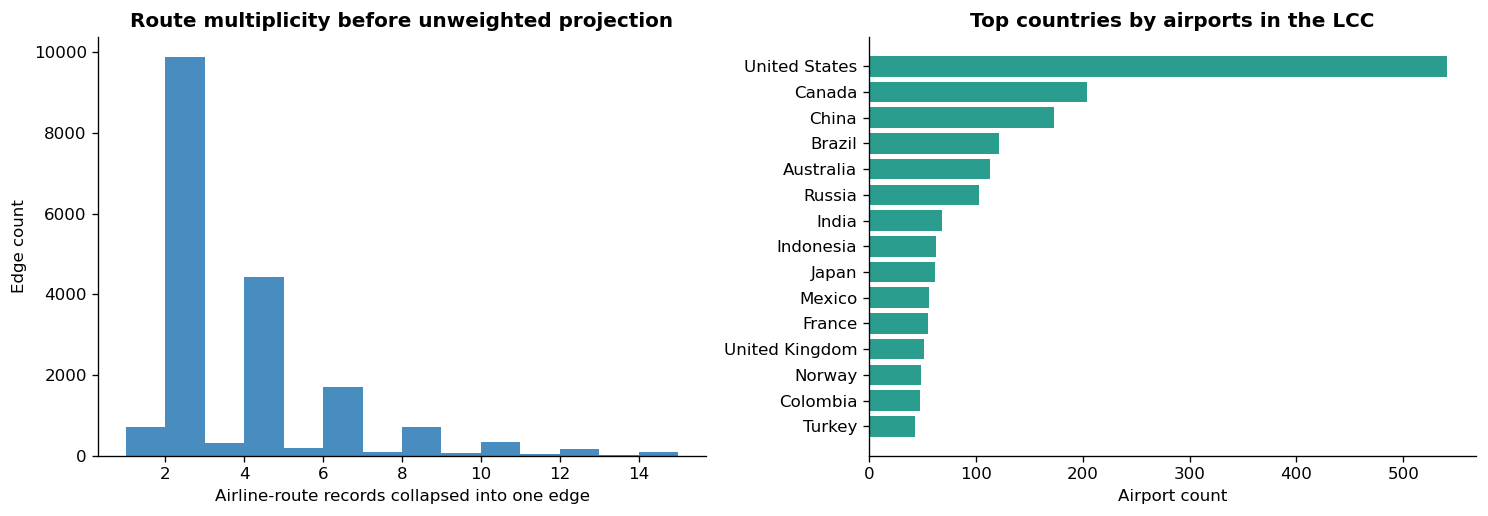

In [5]:
edge_audit = edge_table.copy()
edge_audit["log_multiplicity"] = np.log1p(edge_audit.route_multiplicity)
route_compression = pd.Series({
    "Raw directed airline-route records": len(routes),
    "Unique undirected airport pairs": len(edge_table),
    "Mean route multiplicity per pair": edge_table.route_multiplicity.mean(),
    "Median route multiplicity per pair": edge_table.route_multiplicity.median(),
    "Pairs served by >=3 airline records": (edge_table.route_multiplicity >= 3).mean(),
    "Pairs served by >=5 airline records": (edge_table.route_multiplicity >= 5).mean(),
})
display(route_compression.to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].hist(edge_table.route_multiplicity, bins=np.arange(1, edge_table.route_multiplicity.quantile(.99)+2),
             color=COLORS["blue"], alpha=.85)
axes[0].set(title="Route multiplicity before unweighted projection",
            xlabel="Airline-route records collapsed into one edge", ylabel="Edge count")
country_counts = pd.Series([G.nodes[v]["country"] for v in G]).value_counts().head(15)
axes[1].barh(country_counts.index[::-1], country_counts.values[::-1], color=COLORS["teal"])
axes[1].set(title="Top countries by airports in the LCC", xlabel="Airport count")
plt.tight_layout(); plt.show()

## 4. Exploratory Data Analysis

EDA is used to diagnose graph concentration, geography, and potential modeling difficulty. It does not test the confirmatory hypotheses. Edge lines in the map are sampled for rendering only; every computation uses the complete LCC.

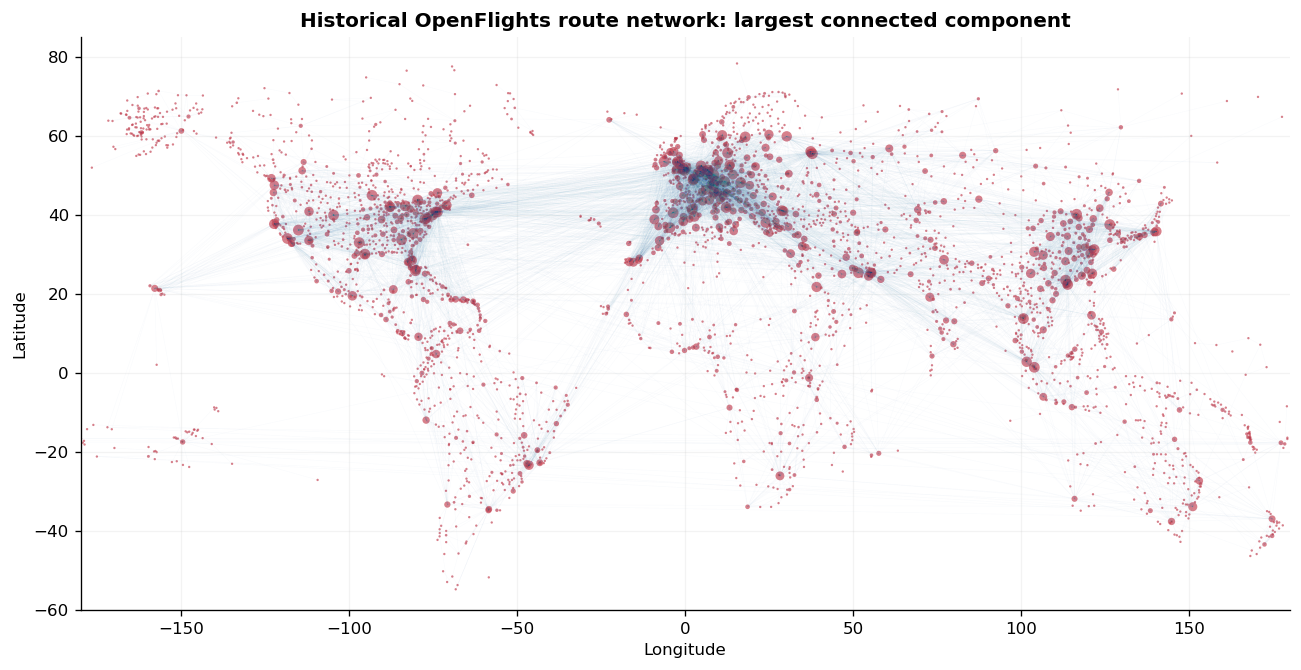

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.2))
rng = np.random.default_rng(MASTER_SEED)
edges = list(G.edges())
for idx in rng.choice(len(edges), size=min(12000, len(edges)), replace=False):
    u, v = edges[idx]
    ax.plot([G.nodes[u]["longitude"], G.nodes[v]["longitude"]],
            [G.nodes[u]["latitude"], G.nodes[v]["latitude"]],
            color=COLORS["blue"], alpha=0.025, lw=0.35)
sizes = np.clip(np.array([G.degree(v) for v in G]) * 0.35, 2, 42)
ax.scatter([G.nodes[v]["longitude"] for v in G],
           [G.nodes[v]["latitude"] for v in G],
           s=sizes, color=COLORS["red"], alpha=0.65, linewidths=0)
ax.set(xlim=(-180,180), ylim=(-60,85), xlabel="Longitude", ylabel="Latitude",
       title="Historical OpenFlights route network: largest connected component")
ax.grid(alpha=.15)
plt.show()

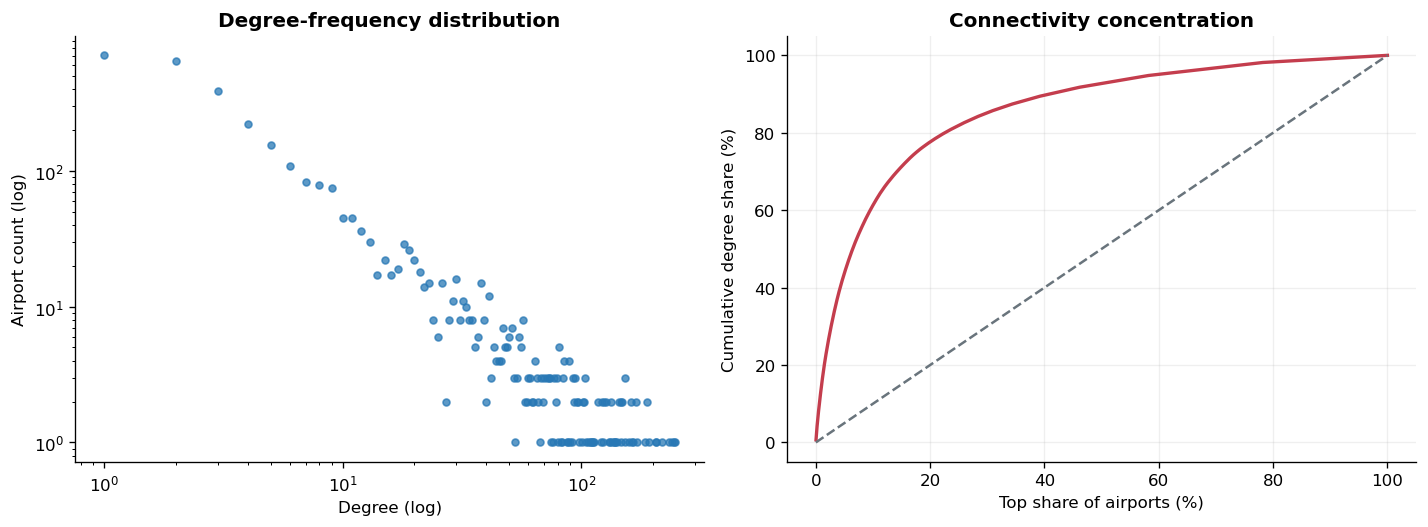

Top 1% of airports hold 14.8% of all edge endpoints.


In [7]:
counts = pd.Series(degrees).value_counts().sort_index()
sorted_deg = np.sort(degrees)[::-1]
cum = np.cumsum(sorted_deg) / sorted_deg.sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(counts.index, counts.values, s=17, color=COLORS["blue"], alpha=.75)
axes[0].set(xscale="log", yscale="log", xlabel="Degree (log)",
            ylabel="Airport count (log)", title="Degree-frequency distribution")
share = np.arange(1, n+1)/n
axes[1].plot(share*100, cum*100, color=COLORS["red"], lw=2)
axes[1].plot([0,100],[0,100],"--",color=COLORS["gray"])
axes[1].set(xlabel="Top share of airports (%)", ylabel="Cumulative degree share (%)",
            title="Connectivity concentration")
axes[1].grid(alpha=.2)
plt.tight_layout(); plt.show()
top1 = max(1, round(.01*n))
print(f"Top 1% of airports hold {cum[top1-1]:.1%} of all edge endpoints.")

### 4.1 Requested node-, relation-, and label-oriented EDA

The dataset is a **homogeneous airport graph**: nodes are airports and all edges represent observed routes. It therefore has no disease nodes, semantic node descriptions, or supplied classification labels. The requested diagnostics are translated into domain-valid counterparts rather than fabricating unavailable variables:

| Requested diagnostic | Airport-network operationalization |
|---|---|
| Degree Distribution | Number of direct airport connections |
| Relation Type by Node Degree | Domestic versus international routes by endpoint degree bucket |
| Hub Nodes – Diseases | Hub airports |
| Node Text Description Lengths | Airport-name length only; no true description field exists |
| Label Entropy Across Nodes | Country diversity among each airport's neighbors |
| Structure–Label Imbalance | Country imbalance across degree buckets |

Country is treated as an **observed descriptive label**, not as a prediction target. These analyses diagnose geographic mixing and representation imbalance.

relation_type,Domestic,International
degree_bucket,,
1 | Leaf,673,32
2-3 | Peripheral,2205,226
4-7 | Local,2208,674
8-15 | Regional,2148,1485
16+ | Hub,10570,17445


relation_type,Domestic,International
Endpoint degree bucket,,
1 | Leaf,95.46,4.54
2-3 | Peripheral,90.70,9.30
4-7 | Local,76.61,23.39
8-15 | Regional,59.12,40.88
16+ | Hub,37.73,62.27


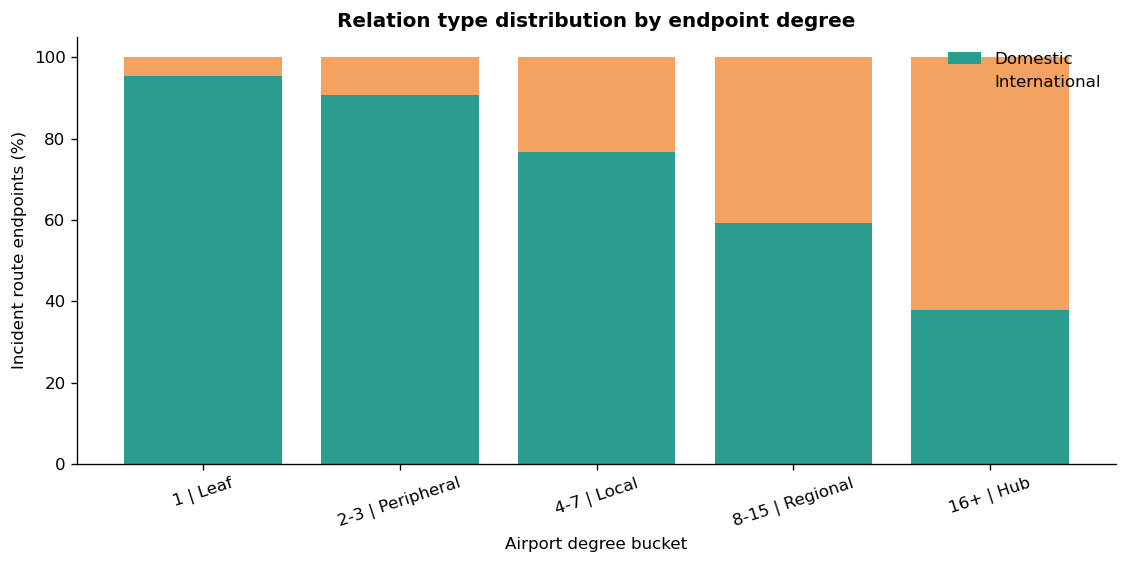

In [8]:
def degree_bucket(value):
    if value <= 1:
        return "1 | Leaf"
    if value <= 3:
        return "2-3 | Peripheral"
    if value <= 7:
        return "4-7 | Local"
    if value <= 15:
        return "8-15 | Regional"
    return "16+ | Hub"

bucket_order = ["1 | Leaf", "2-3 | Peripheral", "4-7 | Local",
                "8-15 | Regional", "16+ | Hub"]
node_eda = pd.DataFrame({
    "node": list(G),
    "degree": [G.degree(v) for v in G],
    "country": [G.nodes[v]["country"] for v in G],
    "iata": [G.nodes[v]["iata"] for v in G],
    "name": [G.nodes[v]["name"] for v in G],
})
node_eda["degree_bucket"] = pd.Categorical(
    node_eda.degree.map(degree_bucket), categories=bucket_order, ordered=True
)

endpoint_rows = []
for u, v in G.edges():
    relation = "Domestic" if G.nodes[u]["country"] == G.nodes[v]["country"] else "International"
    endpoint_rows.extend([
        {"node": u, "degree_bucket": degree_bucket(G.degree(u)), "relation_type": relation},
        {"node": v, "degree_bucket": degree_bucket(G.degree(v)), "relation_type": relation},
    ])
endpoint_relations = pd.DataFrame(endpoint_rows)
relation_distribution = (
    endpoint_relations.groupby(["degree_bucket", "relation_type"], observed=True)
    .size().unstack(fill_value=0).reindex(bucket_order).fillna(0)
)
relation_share = relation_distribution.div(relation_distribution.sum(axis=1), axis=0)

display(relation_distribution.astype(int))
display((100 * relation_share).round(2).rename_axis("Endpoint degree bucket"))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bottom = np.zeros(len(relation_share))
for relation, color in [("Domestic", COLORS["teal"]), ("International", COLORS["orange"])]:
    values = 100 * relation_share[relation].values
    ax.bar(relation_share.index, values, bottom=bottom, label=relation, color=color)
    bottom += values
ax.set(title="Relation type distribution by endpoint degree",
       xlabel="Airport degree bucket", ylabel="Incident route endpoints (%)")
ax.tick_params(axis="x", rotation=18)
ax.legend()
plt.tight_layout()
plt.show()

#### Hub airports

EDA defines hubs by observed degree: the number of direct airport connections. The later centrality section tests whether these degree hubs are also shortest-path brokers or eigenvector-core airports. The table is descriptive and does not imply passenger volume or economic importance.

,iata,name,country,degree,network_share_pct
282,AMS,Amsterdam Airport Schiphol,Netherlands,248,7.782
191,FRA,Frankfurt am Main Airport,Germany,244,7.656
628,CDG,Charles de Gaulle International Airport,France,240,7.531
770,ISL,Atatürk International Airport,Turkey,233,7.311
1802,ATL,Hartsfield Jackson Atlanta International Airport,United States,217,6.809
1877,ORD,Chicago O'Hare International Airport,United States,206,6.464
1635,PEK,Beijing Capital International Airport,China,205,6.432
196,MUC,Munich Airport,Germany,192,6.024
1793,DFW,Dallas Fort Worth International Airport,United States,188,5.899
2007,DME,Domodedovo International Airport,Russia,188,5.899


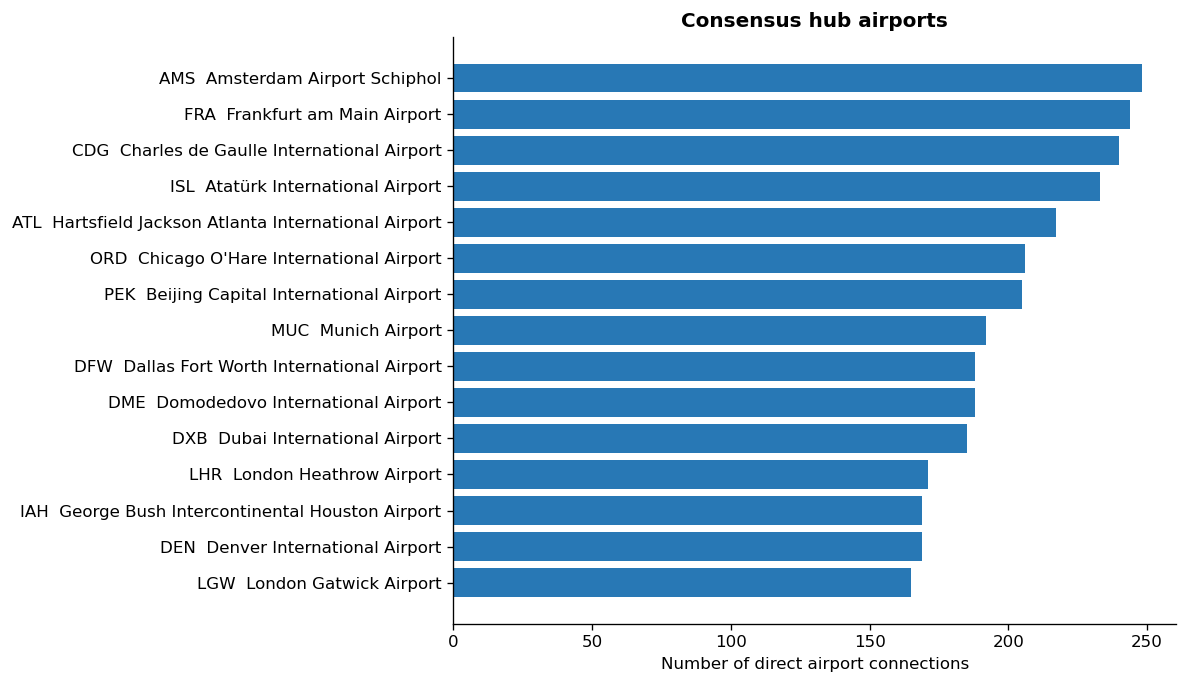

In [9]:
hub_table = node_eda.nlargest(15, "degree").copy()
hub_table["network_share_pct"] = 100 * hub_table.degree / (n - 1)
display(hub_table[[
    "iata", "name", "country", "degree", "network_share_pct"
]].round(3))

fig, ax = plt.subplots(figsize=(10, 5.8))
labels = (hub_table["iata"].replace(r"^\\N$", "", regex=True)
          + "  " + hub_table["name"]).str.strip()
ax.barh(labels[::-1], hub_table.degree[::-1], color=COLORS["blue"])
ax.set(title="Consensus hub airports", xlabel="Number of direct airport connections")
plt.tight_layout()
plt.show()

#### Node text availability and metadata-length audit

OpenFlights supplies an airport name but no free-text node description. Name length is shown only as a metadata-quality diagnostic; it is **not** treated as semantic text and is not used as a GNN feature.

,name_characters,name_tokens
count,3188.0,3188.00
mean,23.8,3.03
std,9.6,1.14
min,9.0,2.00
5%,13.0,2.00
25%,16.0,2.00
50%,21.0,3.00
75%,30.0,4.00
95%,42.0,5.00
max,65.0,8.00


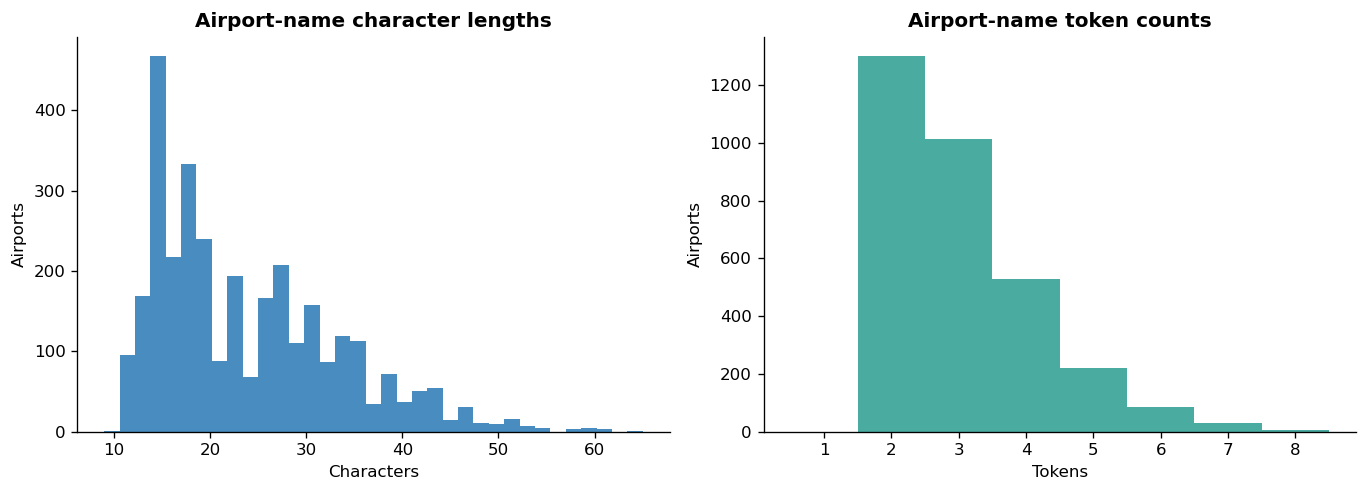

In [10]:
node_eda["name_characters"] = node_eda.name.fillna("").str.len()
node_eda["name_tokens"] = node_eda.name.fillna("").str.split().str.len()
text_audit = node_eda[["name_characters", "name_tokens"]].describe(
    percentiles=[.05, .25, .5, .75, .95]
)
display(text_audit.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].hist(node_eda.name_characters, bins=35, color=COLORS["blue"], alpha=.85)
axes[0].set(title="Airport-name character lengths", xlabel="Characters", ylabel="Airports")
axes[1].hist(node_eda.name_tokens, bins=np.arange(.5, node_eda.name_tokens.max()+1.5),
             color=COLORS["teal"], alpha=.85)
axes[1].set(title="Airport-name token counts", xlabel="Tokens", ylabel="Airports")
plt.tight_layout()
plt.show()

#### Country-label entropy across nodes

For airport \(v\), local label entropy is the Shannon entropy of country labels among its neighbors:

\[
H(v)=-\sum_c p(c\mid N(v))\log_2 p(c\mid N(v)).
\]

Zero entropy means all neighboring airports belong to one country. Higher entropy means the airport connects to a geographically diverse neighborhood. Normalized entropy divides by the maximum entropy possible for that node's degree, allowing airports of different degree to be compared more fairly.

,degree,neighbor_country_entropy,normalized_country_entropy
count,3188.000,3188.000,3188.000
mean,11.815,0.717,0.199
std,25.120,1.224,0.311
min,1.000,-0.000,0.000
25%,2.000,-0.000,-0.000
50%,3.000,-0.000,-0.000
75%,9.000,1.000,0.406
90%,31.000,2.750,0.719
95%,56.000,3.549,0.871
max,248.000,6.013,1.000


,airports,median_degree,mean_entropy_bits,mean_normalized_entropy
degree_bucket,,,,
1 | Leaf,705,1.0,0.000,0.000
2-3 | Peripheral,1023,2.0,0.138,0.110
4-7 | Local,566,5.0,0.567,0.239
8-15 | Regional,348,10.0,1.264,0.376
16+ | Hub,546,36.0,2.533,0.468


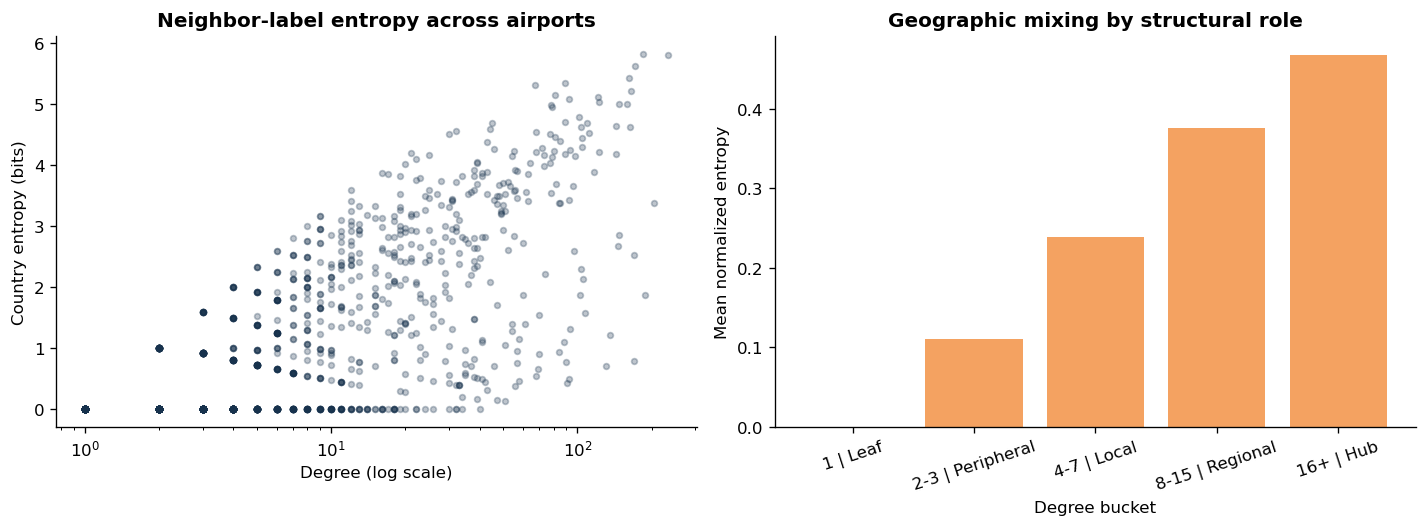

In [11]:
def shannon_bits(values):
    counts = pd.Series(values).value_counts().to_numpy(dtype=float)
    probabilities = counts / counts.sum()
    return float(-(probabilities * np.log2(probabilities)).sum())

local_entropy = {}
normalized_entropy = {}
for v in G:
    labels = [G.nodes[u]["country"] for u in G.neighbors(v)]
    h = shannon_bits(labels)
    max_h = np.log2(max(2, min(len(labels), len(set(node_eda.country)))))
    local_entropy[v] = h
    normalized_entropy[v] = h / max_h if len(labels) > 1 else 0.0

node_eda["neighbor_country_entropy"] = node_eda.node.map(local_entropy)
node_eda["normalized_country_entropy"] = node_eda.node.map(normalized_entropy)
display(node_eda[[
    "degree", "neighbor_country_entropy", "normalized_country_entropy"
]].describe(percentiles=[.25, .5, .75, .9, .95]).round(3))

entropy_by_degree = (node_eda.groupby("degree_bucket", observed=True)
                     .agg(airports=("node", "size"),
                          median_degree=("degree", "median"),
                          mean_entropy_bits=("neighbor_country_entropy", "mean"),
                          mean_normalized_entropy=("normalized_country_entropy", "mean"))
                     .reindex(bucket_order))
display(entropy_by_degree.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sample = node_eda.sample(min(1800, len(node_eda)), random_state=MASTER_SEED)
axes[0].scatter(sample.degree, sample.neighbor_country_entropy, s=12, alpha=.28,
                color=COLORS["navy"])
axes[0].set(xscale="log", xlabel="Degree (log scale)", ylabel="Country entropy (bits)",
            title="Neighbor-label entropy across airports")
axes[1].bar(entropy_by_degree.index, entropy_by_degree.mean_normalized_entropy,
            color=COLORS["orange"])
axes[1].set(xlabel="Degree bucket", ylabel="Mean normalized entropy",
            title="Geographic mixing by structural role")
axes[1].tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

#### Degree buckets reveal structure–label imbalance

Country composition is compared across structural roles. Entropy measures diversity of airport-country labels within each bucket, while the dominant-country share measures concentration. Large differences imply that node degree and geography are associated, so random train/test splitting may preserve a structural-country imbalance rather than eliminate it.

,degree_bucket,airports,represented_countries,country_entropy_bits,normalized_country_entropy,dominant_country,dominant_country_share
0,1 | Leaf,705,107,5.4137,0.8030,United States,0.2184
1,2-3 | Peripheral,1023,125,5.5358,0.7947,United States,0.1691
2,4-7 | Local,566,113,5.6665,0.8308,United States,0.1290
3,8-15 | Regional,348,113,5.6917,0.8345,United States,0.1552
4,16+ | Hub,546,143,5.7428,0.8021,United States,0.1593


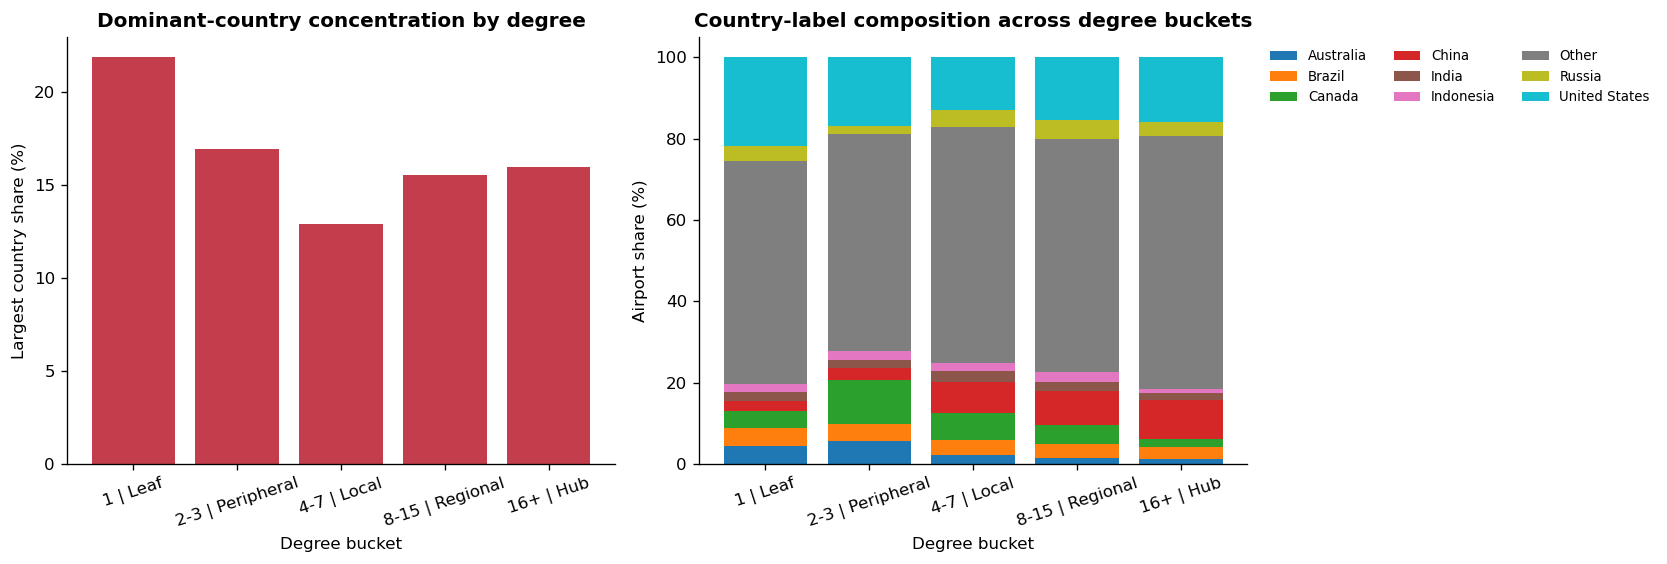

In [12]:
imbalance_rows = []
country_bucket = pd.crosstab(node_eda.degree_bucket, node_eda.country).reindex(bucket_order)
for bucket, counts in country_bucket.iterrows():
    counts = counts[counts > 0]
    p = counts / counts.sum()
    imbalance_rows.append({
        "degree_bucket": bucket,
        "airports": int(counts.sum()),
        "represented_countries": len(counts),
        "country_entropy_bits": float(-(p * np.log2(p)).sum()),
        "normalized_country_entropy": float(-(p * np.log2(p)).sum() / np.log2(len(counts)))
                                      if len(counts) > 1 else 0.0,
        "dominant_country": counts.idxmax(),
        "dominant_country_share": counts.max() / counts.sum(),
    })
degree_label_imbalance = pd.DataFrame(imbalance_rows)
display(degree_label_imbalance.round(4))

top_countries = node_eda.country.value_counts().head(8).index
composition = pd.crosstab(
    node_eda.degree_bucket,
    node_eda.country.where(node_eda.country.isin(top_countries), "Other")
).reindex(bucket_order)
composition = composition.div(composition.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(degree_label_imbalance.degree_bucket,
            degree_label_imbalance.dominant_country_share * 100,
            color=COLORS["red"])
axes[0].set(title="Dominant-country concentration by degree",
            xlabel="Degree bucket", ylabel="Largest country share (%)")
axes[0].tick_params(axis="x", rotation=18)

bottom = np.zeros(len(composition))
palette = plt.cm.tab10(np.linspace(0, 1, composition.shape[1]))
for color, country in zip(palette, composition.columns):
    axes[1].bar(composition.index, 100*composition[country], bottom=bottom,
                label=country, color=color)
    bottom += 100*composition[country].values
axes[1].set(title="Country-label composition across degree buckets",
            xlabel="Degree bucket", ylabel="Airport share (%)")
axes[1].tick_params(axis="x", rotation=18)
axes[1].legend(ncol=3, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.1 Higher-order graph diagnostics

Degree plots show concentration, but a transportation network also needs diagnostics for clustering, assortativity, cores, bridges, and community structure. These diagnostics describe whether the graph is hub-and-spoke, modular by geography, or resilient through redundant local closure.

,diagnostic,value
0,Average clustering,0.492830
1,Transitivity,0.249716
2,Degree assortativity,-0.018062
3,Approx. mean shortest-path length,3.908597
4,Approx. 90th percentile distance,5.000000
5,Maximum k-core,31.000000
6,Airports in maximum core,93.000000
7,Articulation airports,329.000000
8,Bridge edges,746.000000
9,Greedy modularity communities,42.000000


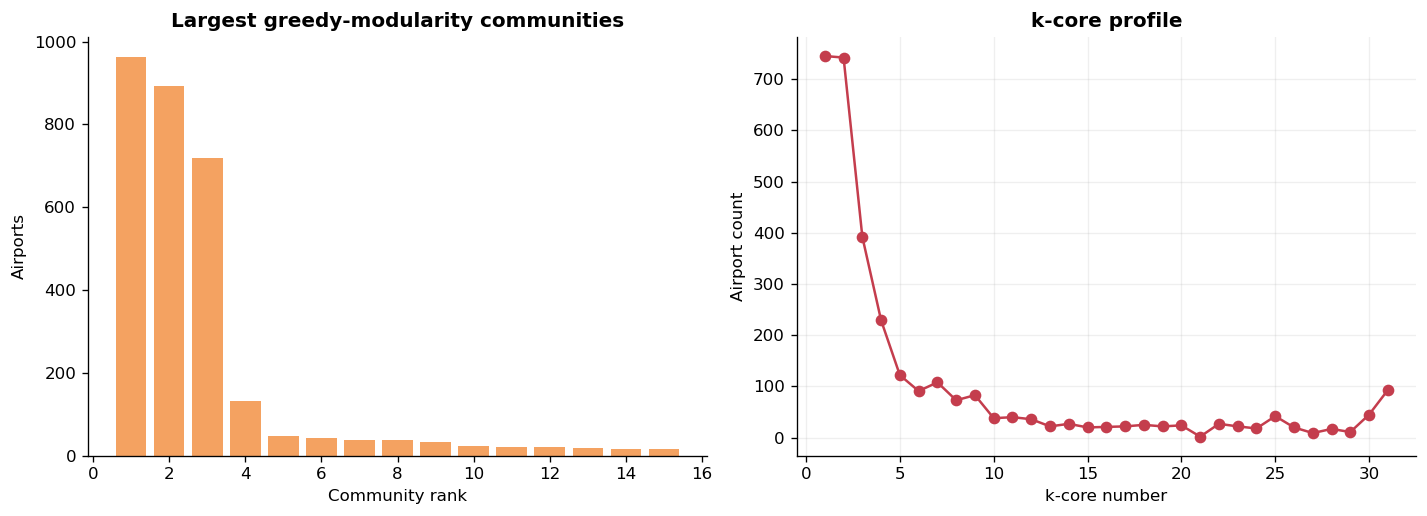

In [13]:
def approximate_average_distance(graph, samples=120, seed=MASTER_SEED):
    rng = np.random.default_rng(seed)
    sample_nodes = rng.choice(list(graph), size=min(samples, graph.number_of_nodes()), replace=False)
    dists = []
    for s in sample_nodes:
        lengths = nx.single_source_shortest_path_length(graph, int(s))
        dists.extend([d for v, d in lengths.items() if v != s])
    return float(np.mean(dists)), float(np.quantile(dists, .90))

core_numbers = nx.core_number(G)
articulation = list(nx.articulation_points(G))
bridges = list(nx.bridges(G))
avg_dist, p90_dist = approximate_average_distance(G)
communities = list(nx.community.greedy_modularity_communities(G))
modularity = nx.community.modularity(G, communities)

diagnostics = pd.DataFrame({
    "diagnostic": [
        "Average clustering", "Transitivity", "Degree assortativity",
        "Approx. mean shortest-path length", "Approx. 90th percentile distance",
        "Maximum k-core", "Airports in maximum core", "Articulation airports",
        "Bridge edges", "Greedy modularity communities", "Greedy modularity score"
    ],
    "value": [
        nx.average_clustering(G), nx.transitivity(G), nx.degree_assortativity_coefficient(G),
        avg_dist, p90_dist, max(core_numbers.values()),
        sum(v == max(core_numbers.values()) for v in core_numbers.values()),
        len(articulation), len(bridges), len(communities), modularity
    ]
})
display(diagnostics)

community_id = {}
for cid, members in enumerate(communities):
    for v in members:
        community_id[v] = cid
community_sizes = pd.Series([len(c) for c in communities]).sort_values(ascending=False)
kcore_counts = pd.Series(core_numbers).value_counts().sort_index()

top_communities = community_sizes.head(15)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].bar(range(1, len(top_communities) + 1), top_communities,
            color=COLORS["orange"])
axes[0].set(title="Largest greedy-modularity communities", xlabel="Community rank", ylabel="Airports")
axes[1].plot(kcore_counts.index, kcore_counts.values, "o-", color=COLORS["red"])
axes[1].set(title="k-core profile", xlabel="k-core number", ylabel="Airport count")
axes[1].grid(alpha=.2)
plt.tight_layout(); plt.show()

## 5. Centrality Analysis and Attack Definition

Degree measures direct reach, betweenness measures shortest-path brokerage, and eigenvector centrality rewards connections to influential neighbors. Their rankings are expected to overlap but not coincide. This distinction motivates three attack strategies rather than treating “centrality” as a single construct.

Betweenness is approximated with 250 seeded source nodes for computational tractability. Approximation uncertainty is acknowledged; attack rankings remain deterministic under the recorded seed.

In [14]:
t0 = time.time()
centralities = {
    "Degree": nx.degree_centrality(G),
    "Betweenness": nx.betweenness_centrality(G, k=min(250,n), seed=MASTER_SEED),
    "Eigenvector": nx.eigenvector_centrality(G, max_iter=1500, tol=1e-7)
}
cent = pd.DataFrame(centralities)
cent["name"] = [G.nodes[v]["name"] for v in cent.index]
cent["iata"] = [G.nodes[v]["iata"] for v in cent.index]
cent["country"] = [G.nodes[v]["country"] for v in cent.index]
print(f"Centralities computed in {time.time()-t0:.1f}s")
for metric in centralities:
    print(f"\nTop 10 by {metric}")
    display(cent.nlargest(10, metric)[["iata","name","country",metric]])

Centralities computed in 3.5s

Top 10 by Degree


,iata,name,country,Degree
580,AMS,Amsterdam Airport Schiphol,Netherlands,0.077816
340,FRA,Frankfurt am Main Airport,Germany,0.076561
1382,CDG,Charles de Gaulle International Airport,France,0.075306
1701,ISL,Atatürk International Airport,Turkey,0.073110
3682,ATL,Hartsfield Jackson Atlanta International Airport,United States,0.068089
3830,ORD,Chicago O'Hare International Airport,United States,0.064638
3364,PEK,Beijing Capital International Airport,China,0.064324
346,MUC,Munich Airport,Germany,0.060245
3670,DFW,Dallas Fort Worth International Airport,United States,0.058990
4029,DME,Domodedovo International Airport,Russia,0.058990



Top 10 by Betweenness


,iata,name,country,Betweenness
3774,ANC,Ted Stevens Anchorage International Airport,United States,0.065789
3484,LAX,Los Angeles International Airport,United States,0.064190
2188,DXB,Dubai International Airport,United Arab Emirates,0.062715
1382,CDG,Charles de Gaulle International Airport,France,0.062450
3830,ORD,Chicago O'Hare International Airport,United States,0.056488
3364,PEK,Beijing Capital International Airport,China,0.051328
580,AMS,Amsterdam Airport Schiphol,Netherlands,0.049990
340,FRA,Frankfurt am Main Airport,Germany,0.049602
3361,SYD,Sydney Kingsford Smith International Airport,Australia,0.046641
1701,ISL,Atatürk International Airport,Turkey,0.046306



Top 10 by Eigenvector


,iata,name,country,Eigenvector
580,AMS,Amsterdam Airport Schiphol,Netherlands,0.167943
340,FRA,Frankfurt am Main Airport,Germany,0.166439
1382,CDG,Charles de Gaulle International Airport,France,0.159501
346,MUC,Munich Airport,Germany,0.148602
1555,FCO,Leonardo da Vinci–Fiumicino Airport,Italy,0.136391
507,LHR,London Heathrow Airport,United Kingdom,0.135957
1701,ISL,Atatürk International Airport,Turkey,0.129210
1218,BCN,Barcelona International Airport,Spain,0.128227
1678,ZRH,Zürich Airport,Switzerland,0.126062
1229,MAD,Adolfo Suárez Madrid–Barajas Airport,Spain,0.123042


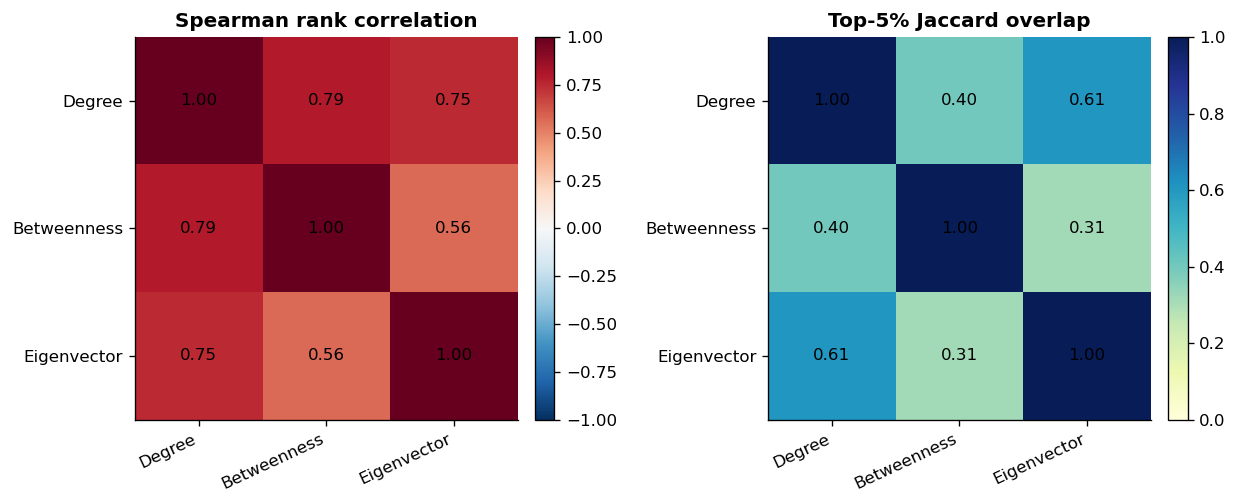

In [15]:
rank_corr = cent[["Degree","Betweenness","Eigenvector"]].corr(method="spearman")
top_sets = {c: set(cent.nlargest(round(.05*n), c).index)
            for c in ["Degree","Betweenness","Eigenvector"]}
overlap = pd.DataFrame(index=top_sets, columns=top_sets, dtype=float)
for a in top_sets:
    for b in top_sets:
        overlap.loc[a,b] = len(top_sets[a]&top_sets[b]) / len(top_sets[a]|top_sets[b])

fig, axes = plt.subplots(1,2,figsize=(10.5,4.3))
for ax, mat, title, cmap in [
    (axes[0], rank_corr, "Spearman rank correlation", "RdBu_r"),
    (axes[1], overlap, "Top-5% Jaccard overlap", "YlGnBu")
]:
    im=ax.imshow(mat.astype(float),vmin=0 if "Jaccard" in title else -1,vmax=1,cmap=cmap)
    ax.set_xticks(range(3),mat.columns,rotation=25,ha="right")
    ax.set_yticks(range(3),mat.index)
    for i in range(3):
        for j in range(3):
            ax.text(j,i,f"{mat.iloc[i,j]:.2f}",ha="center",va="center")
    ax.set_title(title); fig.colorbar(im,ax=ax,fraction=.046,pad=.04)
plt.tight_layout(); plt.show()

### 5.1 Centrality is multi-dimensional, not a single ranking

The lecturer's phrasing about “who was central is no longer central” requires treating centrality as a family of constructs. The code below builds a standardized hubness profile, classifies airports by centrality role, and quantifies whether the same airports are selected by different centrality definitions.

,airports,mean_degree,mean_betweenness,mean_eigenvector,mean_dispersion
centrality_specialization,,,,,
Betweenness,2228,0.00156,0.00084,0.00177,0.30326
Eigenvector,559,0.00799,0.00082,0.02190,0.97547
Degree,401,0.00967,0.00155,0.01172,0.70992


,iata,name,country,Degree,Betweenness,Eigenvector,centrality_specialization,centrality_dispersion
1382,CDG,Charles de Gaulle International Airport,France,0.07531,0.06245,0.15950,Betweenness,4.59350
580,AMS,Amsterdam Airport Schiphol,Netherlands,0.07782,0.04999,0.16794,Betweenness,1.50485
340,FRA,Frankfurt am Main Airport,Germany,0.07656,0.04960,0.16644,Betweenness,1.57779
1701,ISL,Atatürk International Airport,Turkey,0.07311,0.04631,0.12921,Betweenness,2.63503
2188,DXB,Dubai International Airport,United Arab Emirates,0.05805,0.06272,0.10349,Betweenness,7.84645
3830,ORD,Chicago O'Hare International Airport,United States,0.06464,0.05649,0.08991,Betweenness,7.28723
3364,PEK,Beijing Capital International Airport,China,0.06432,0.05133,0.08343,Betweenness,6.53372
3484,LAX,Los Angeles International Airport,United States,0.04644,0.06419,0.07556,Betweenness,9.87175
507,LHR,London Heathrow Airport,United Kingdom,0.05366,0.03902,0.13596,Betweenness,2.13163
3682,ATL,Hartsfield Jackson Atlanta International Airport,United States,0.06809,0.03642,0.08117,Degree,3.63470


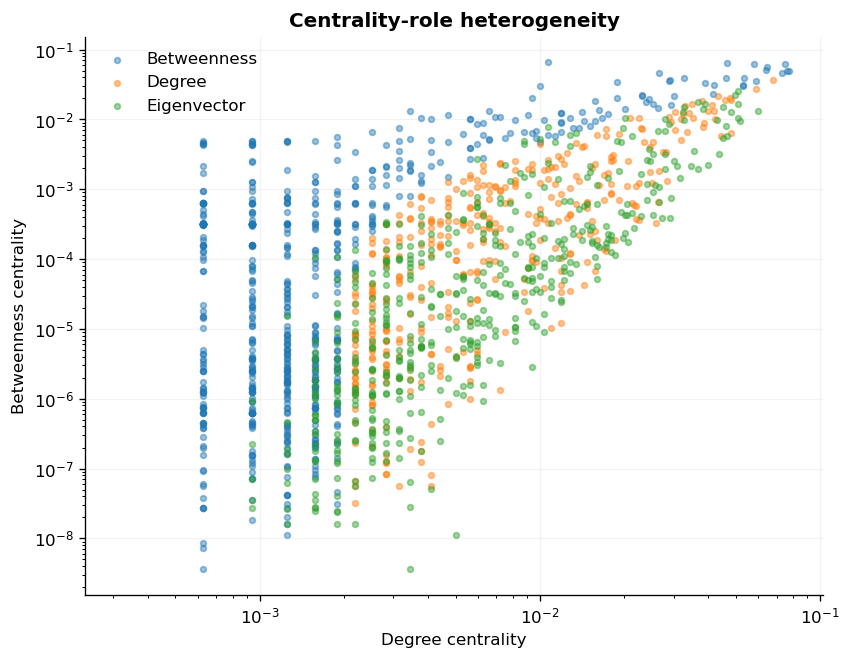

PCA explained variance ratio: [0.829 0.152]


In [16]:
from sklearn.decomposition import PCA

centrality_z = cent[["Degree", "Betweenness", "Eigenvector"]].copy()
centrality_z = (centrality_z - centrality_z.mean()) / centrality_z.std(ddof=0)
pca = PCA(n_components=2, random_state=MASTER_SEED)
pc = pca.fit_transform(centrality_z)
cent["hubness_pc1"] = pc[:, 0]
cent["centrality_specialization"] = centrality_z.idxmax(axis=1)
cent["centrality_dispersion"] = centrality_z.max(axis=1) - centrality_z.min(axis=1)

profile = (cent.groupby("centrality_specialization")
           .agg(airports=("name","count"),
                mean_degree=("Degree","mean"),
                mean_betweenness=("Betweenness","mean"),
                mean_eigenvector=("Eigenvector","mean"),
                mean_dispersion=("centrality_dispersion","mean"))
           .sort_values("airports", ascending=False))
display(profile.round(5))

display(cent.nlargest(15, "hubness_pc1")[[
    "iata", "name", "country", "Degree", "Betweenness", "Eigenvector",
    "centrality_specialization", "centrality_dispersion"
]].round(5))

fig, ax = plt.subplots(figsize=(7.2, 5.6))
for role, d in cent.groupby("centrality_specialization"):
    ax.scatter(d["Degree"], d["Betweenness"], s=12, alpha=.45, label=role)
ax.set(xscale="log", yscale="log", xlabel="Degree centrality", ylabel="Betweenness centrality",
       title="Centrality-role heterogeneity")
ax.legend()
ax.grid(alpha=.15)
plt.tight_layout(); plt.show()
print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

### 5.2 Sensitivity to the unweighted graph abstraction

The main graph treats every airport pair as one edge. A sensitivity graph instead uses route multiplicity as edge weight. Weighted shortest-path centrality uses inverse multiplicity as distance, so frequently served links are treated as closer. Agreement between weighted and unweighted rankings indicates that the centrality claims are not merely artifacts of collapsing airline-level records.

In [17]:
Gw = nx.Graph()
Gw.add_nodes_from(G.nodes(data=True))
for row in edge_table.itertuples(index=False):
    if row.u in G and row.v in G:
        Gw.add_edge(row.u, row.v, weight=float(row.route_multiplicity),
                    distance=1.0 / float(row.route_multiplicity))

weighted_cent = {
    "Strength": dict(Gw.degree(weight="weight")),
    "Weighted betweenness": nx.betweenness_centrality(
        Gw, k=min(250, n), weight="distance", seed=MASTER_SEED
    ),
    "Weighted eigenvector": nx.eigenvector_centrality(
        Gw, weight="weight", max_iter=1500, tol=1e-7
    ),
}
weighted_pairs = [
    ("Degree", "Strength"),
    ("Betweenness", "Weighted betweenness"),
    ("Eigenvector", "Weighted eigenvector"),
]
sensitivity_rows = []
for unweighted_name, weighted_name in weighted_pairs:
    a = pd.Series(centralities[unweighted_name])
    b = pd.Series(weighted_cent[weighted_name])
    k = round(.05 * n)
    sensitivity_rows.append({
        "centrality construct": unweighted_name,
        "Spearman rank agreement": spearmanr(a, b).statistic,
        "Top-5% Jaccard": len(set(a.nlargest(k).index) & set(b.nlargest(k).index)) /
                          len(set(a.nlargest(k).index) | set(b.nlargest(k).index)),
    })
weighted_sensitivity = pd.DataFrame(sensitivity_rows)
display(weighted_sensitivity.round(4))

,centrality construct,Spearman rank agreement,Top-5% Jaccard
0,Degree,0.9526,0.7473
1,Betweenness,0.7551,0.7966
2,Eigenvector,0.9486,0.4133


## 6. Structural Robustness Methodology

For graph \(G=(V,E)\), attack budget \(q\) removes \(k=\lfloor q|V|\rceil\) nodes. Budgets are \(q\in\{0,1,3,5,10,15\%\}\). Targeted attacks remove nodes in descending baseline centrality order. Random failure is repeated 8 times at each nonzero budget.

### Outcomes

1. **LCC retention:** \(|V_{\mathrm{LCC}}|/|V_{\mathrm{remaining}}|\).
2. **Edge retention:** \(|E_q|/|E_0|\).
3. **Approximate global efficiency:** sampled mean reciprocal shortest-path distance.
4. **Centrality stability:** Spearman correlation of surviving degree ranks with baseline ranks.
5. **Fragmentation:** connected-component count.
6. **Algebraic connectivity:** second-smallest eigenvalue \(\lambda_2\) of
   \[
   L_{\mathrm{sym}}=I-D^{-1/2}AD^{-1/2}.
   \]
7. **Spectral displacement:** Euclidean distance between the first nontrivial normalized-Laplacian eigenvalues.

Because \(\lambda_2\) is calculated on the surviving LCC, component count and LCC retention must be interpreted alongside it. Otherwise, discarding fragments could misleadingly make the remaining core appear more cohesive.

In [18]:
def spectrum(graph, k=10):
    if graph.number_of_nodes() < 3:
        return np.array([0.0])
    nodes = list(graph)
    A = nx.to_scipy_sparse_array(graph, nodelist=nodes, format="csr", dtype=float)
    d = np.asarray(A.sum(axis=1)).ravel()
    inv = np.zeros_like(d)
    inv[d>0] = 1/np.sqrt(d[d>0])
    L = sparse.eye(len(nodes), format="csr") - sparse.diags(inv) @ A @ sparse.diags(inv)
    vals = eigsh(L, k=min(k,len(nodes)-1), which="SM",
                 return_eigenvectors=False, tol=1e-4)
    return np.sort(np.clip(vals,0,None))

def approx_efficiency(graph, samples=80, seed=MASTER_SEED):
    if graph.number_of_nodes()<2: return 0.0
    rng=np.random.default_rng(seed)
    nodes=list(graph)
    sources=rng.choice(nodes,size=min(samples,len(nodes)),replace=False)
    total=0.0
    for s in sources:
        total += sum(1/d for v,d in nx.single_source_shortest_path_length(graph,s).items()
                     if v!=s and d>0)
    return total/(len(sources)*(len(nodes)-1))

baseline_spec=spectrum(G)
baseline_rank=pd.Series(dict(G.degree())).rank(ascending=False,method="average")
baseline_eff=approx_efficiency(G)

def graph_metrics(graph, strategy, budget, replicate=0):
    comps=sorted(nx.connected_components(graph),key=len,reverse=True)
    lcc=graph.subgraph(comps[0]).copy()
    deg=pd.Series(dict(graph.degree()))
    common=baseline_rank.index.intersection(deg.index)
    rho=spearmanr(baseline_rank.loc[common],
                  deg.loc[common].rank(ascending=False,method="average")).statistic
    sp=spectrum(lcc)
    kk=min(len(sp),len(baseline_spec))
    return {
        "strategy":strategy,"budget":budget,"replicate":replicate,
        "nodes":graph.number_of_nodes(),"edges":graph.number_of_edges(),
        "edge_retention":graph.number_of_edges()/m,
        "components":len(comps),"lcc_retention":lcc.number_of_nodes()/graph.number_of_nodes(),
        "efficiency":approx_efficiency(graph,seed=MASTER_SEED+replicate),
        "degree_rank_rho":rho,"lambda2":sp[1] if len(sp)>1 else 0.0,
        "spectral_distance":np.linalg.norm(baseline_spec[1:kk]-sp[1:kk])
    }

In [19]:
budgets=[0,.01,.03,.05,.10,.15]
rankings={name:list(pd.Series(values).sort_values(ascending=False).index)
          for name,values in centralities.items()}
rows=[graph_metrics(G,"Baseline",0,0)]
for strategy,ranking in rankings.items():
    for q in budgets[1:]:
        H=G.copy(); H.remove_nodes_from(ranking[:round(q*n)])
        rows.append(graph_metrics(H,strategy,q,0))
for q in budgets[1:]:
    for rep in range(8):
        rng=np.random.default_rng(MASTER_SEED+1000*round(q*100)+rep)
        H=G.copy()
        H.remove_nodes_from(rng.choice(list(G),size=round(q*n),replace=False))
        rows.append(graph_metrics(H,"Random",q,rep))
structural=pd.DataFrame(rows)
display(structural.head())

,strategy,budget,replicate,nodes,edges,edge_retention,components,lcc_retention,efficiency,degree_rank_rho,lambda2,spectral_distance
0,Baseline,0.00,0,3188,18833,1.000000,1,1.000000,0.268759,1.000000,0.019220,2.297440e-11
1,Degree,0.01,0,3156,13586,0.721393,112,0.962928,0.244169,0.968428,0.015817,2.974799e-02
2,Degree,0.03,0,3092,8508,0.451760,325,0.886158,0.165989,0.879583,0.003633,8.225220e-02
3,Degree,0.05,0,3029,5870,0.311687,519,0.812810,0.104390,0.798224,0.001930,1.067498e-01
4,Degree,0.10,0,2869,2924,0.155259,969,0.156849,0.011017,0.568863,0.000803,8.370105e-02


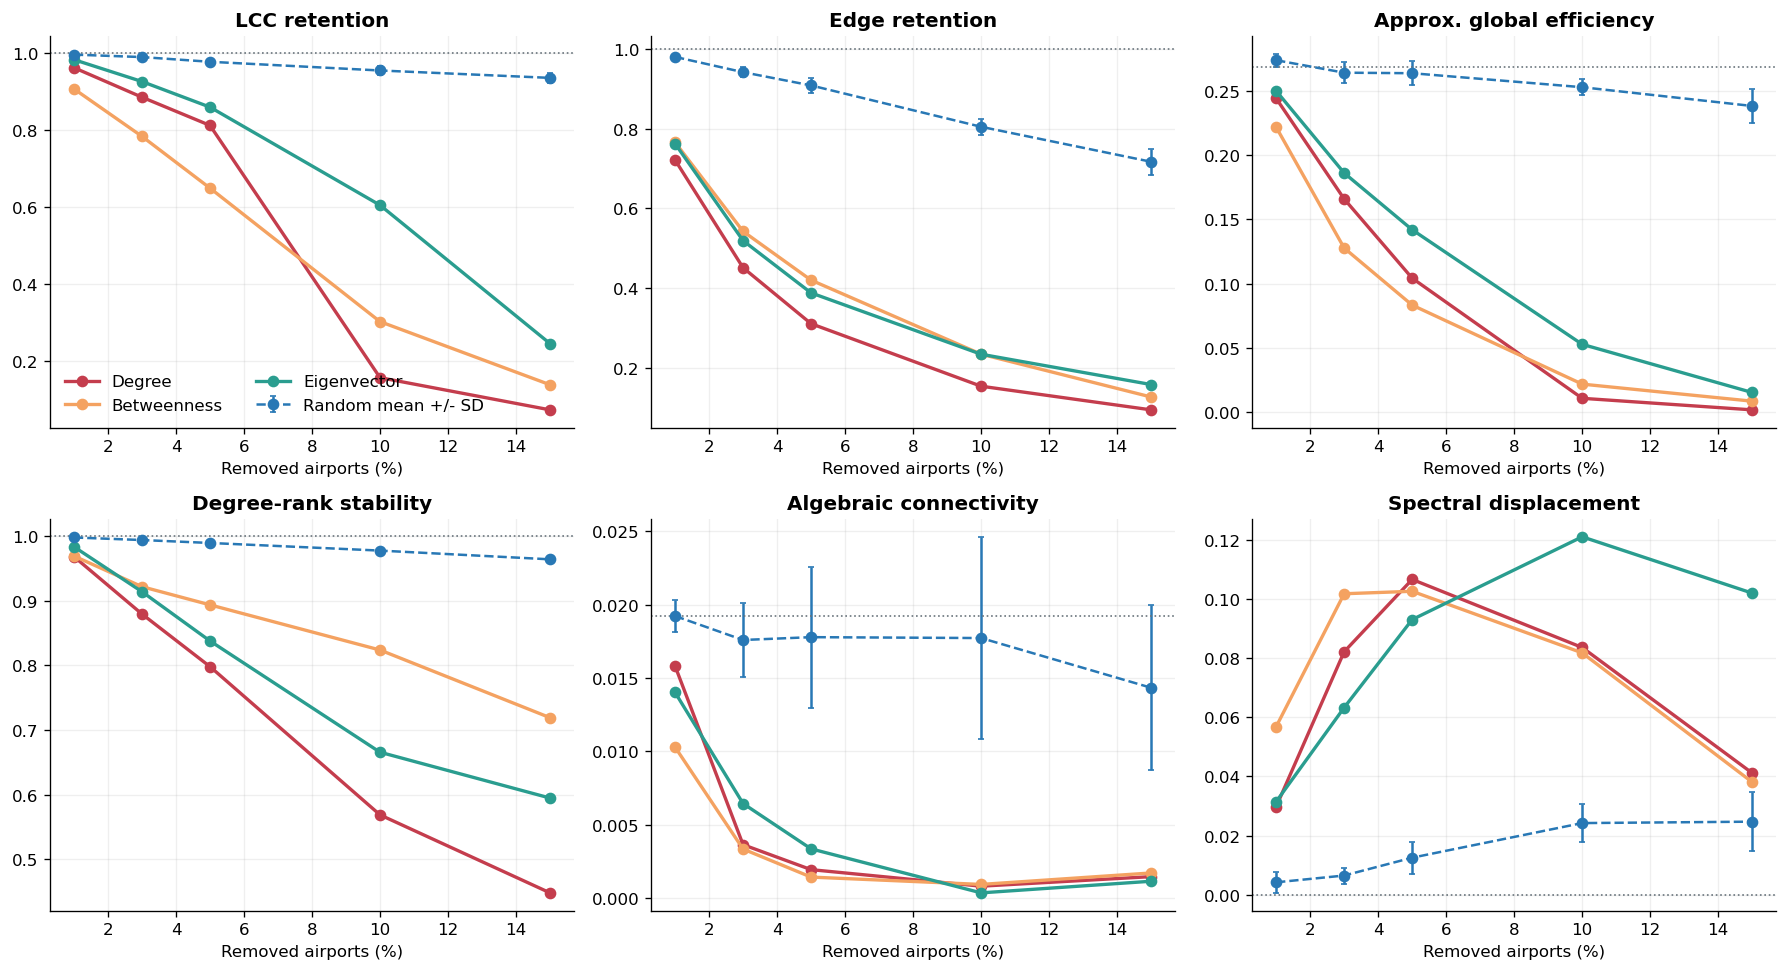

In [20]:
plot_metrics=[
    ("lcc_retention","LCC retention"),("edge_retention","Edge retention"),
    ("efficiency","Approx. global efficiency"),("degree_rank_rho","Degree-rank stability"),
    ("lambda2","Algebraic connectivity"),("spectral_distance","Spectral displacement")
]
fig,axes=plt.subplots(2,3,figsize=(15,8.2))
palette={"Degree":COLORS["red"],"Betweenness":COLORS["orange"],
         "Eigenvector":COLORS["teal"],"Random":COLORS["blue"]}
for ax,(metric,title) in zip(axes.flat,plot_metrics):
    for strategy in ["Degree","Betweenness","Eigenvector"]:
        d=structural[structural.strategy==strategy]
        ax.plot(d.budget*100,d[metric],"o-",label=strategy,color=palette[strategy],lw=2)
    r=(structural[structural.strategy=="Random"].groupby("budget")[metric]
       .agg(["mean","std"]).reset_index())
    ax.errorbar(r.budget*100,r["mean"],yerr=r["std"],fmt="o--",capsize=2,
                color=palette["Random"],label="Random mean +/- SD")
    base=structural.loc[structural.strategy=="Baseline",metric].iloc[0]
    ax.axhline(base,color=COLORS["gray"],ls=":",lw=1)
    ax.set(title=title,xlabel="Removed airports (%)")
    ax.grid(alpha=.2)
axes[0,0].legend(ncol=2)
plt.tight_layout(); plt.show()

### 6.1 Integrated robustness index

Point estimates at one budget can be unstable or selectively reported. We therefore summarize each attack curve using normalized area under the robustness curve (AURC) over 0–15% removal. Higher AURC means better preservation. For damage metrics such as spectral distance, the complement after min–max normalization is reported so that all indices share the same direction.

In [21]:
def normalized_auc(x,y):
    return np.trapz(y,x)/(x.max()-x.min())

base_row=structural[structural.strategy=="Baseline"].iloc[0]
aurc_rows=[]
for strategy in ["Degree","Betweenness","Eigenvector"]:
    d=structural[structural.strategy==strategy].sort_values("budget")
    for metric in ["lcc_retention","edge_retention","efficiency","degree_rank_rho","lambda2"]:
        x=np.r_[0,d.budget.values]; y=np.r_[base_row[metric],d[metric].values]
        aurc_rows.append({"strategy":strategy,"metric":metric,"AURC":normalized_auc(x,y)})
rmean=(structural[structural.strategy=="Random"].groupby("budget").mean(numeric_only=True)
       .reset_index().sort_values("budget"))
for metric in ["lcc_retention","edge_retention","efficiency","degree_rank_rho","lambda2"]:
    x=np.r_[0,rmean.budget.values]; y=np.r_[base_row[metric],rmean[metric].values]
    aurc_rows.append({"strategy":"Random","metric":metric,"AURC":normalized_auc(x,y)})
aurc=pd.DataFrame(aurc_rows)
display(aurc.pivot(index="strategy",columns="metric",values="AURC").round(4))

metric,degree_rank_rho,edge_retention,efficiency,lambda2,lcc_retention
strategy,,,,,
Betweenness,0.8563,0.3803,0.0765,0.0030,0.5042
Degree,0.6980,0.3062,0.0839,0.0037,0.5019
Eigenvector,0.7702,0.3745,0.1122,0.0040,0.6988
Random,0.9832,0.8563,0.2571,0.0174,0.9680


### 6.3 Targeted attack effect sizes against random failure

The robustness curves are useful visually, but the scientific comparison is a matched contrast: targeted attack minus the random-failure distribution at the same budget. The table below reports z-score style effect sizes relative to random repetitions. Large negative values for preservation metrics indicate damage beyond random graph shrinkage.

In [22]:
effect_rows = []
for metric in ["lcc_retention", "edge_retention", "efficiency", "degree_rank_rho", "lambda2"]:
    random_stats = (structural[structural.strategy == "Random"]
                    .groupby("budget")[metric].agg(["mean", "std"]).reset_index())
    for strategy in ["Degree", "Betweenness", "Eigenvector"]:
        d = structural[structural.strategy == strategy][["budget", metric]]
        merged = d.merge(random_stats, on="budget")
        for row in merged.itertuples(index=False):
            sd = row.std if row.std and row.std > 1e-12 else np.nan
            effect_rows.append({
                "metric": metric, "strategy": strategy, "budget": row.budget,
                "targeted_value": getattr(row, metric), "random_mean": row.mean,
                "targeted_minus_random": getattr(row, metric) - row.mean,
                "z_vs_random": (getattr(row, metric) - row.mean) / sd if sd == sd else np.nan
            })
effects = pd.DataFrame(effect_rows)
display(effects[effects.budget.isin([.03, .10, .15])]
        .pivot_table(index=["metric", "budget"], columns="strategy",
                     values="targeted_minus_random").round(4))
display(effects[effects.budget == .10]
        .sort_values(["metric", "z_vs_random"])[
            ["metric","strategy","targeted_value","random_mean","targeted_minus_random","z_vs_random"]
        ].round(4))

strategy                Betweenness  Degree  Eigenvector
metric          budget                                  
degree_rank_rho 0.03        -0.0722 -0.1145      -0.0799
                0.10        -0.1538 -0.4089      -0.3119
                0.15        -0.2450 -0.5160      -0.3693
edge_retention  0.03        -0.3983 -0.4894      -0.4216
                0.10        -0.5690 -0.6492      -0.5692
                0.15        -0.5887 -0.6209      -0.5575
efficiency      0.03        -0.1363 -0.0981      -0.0780
                0.10        -0.2308 -0.2418      -0.1998
                0.15        -0.2294 -0.2362      -0.2227
lambda2         0.03        -0.0143 -0.0140      -0.0112
                0.10        -0.0168 -0.0169      -0.0174
                0.15        -0.0126 -0.0129      -0.0132
lcc_retention   0.03        -0.2063 -0.1044      -0.0636
                0.10        -0.6531 -0.7988      -0.3502
                0.15        -0.7981 -0.8634      -0.6911

,metric,strategy,targeted_value,random_mean,targeted_minus_random,z_vs_random
48,degree_rank_rho,Degree,0.5689,0.9777,-0.4089,-197.0947
58,degree_rank_rho,Eigenvector,0.6658,0.9777,-0.3119,-150.3722
53,degree_rank_rho,Betweenness,0.8239,0.9777,-0.1538,-74.1471
18,edge_retention,Degree,0.1553,0.8045,-0.6492,-31.3623
28,edge_retention,Eigenvector,0.2353,0.8045,-0.5692,-27.4967
23,edge_retention,Betweenness,0.2354,0.8045,-0.5690,-27.4890
33,efficiency,Degree,0.0110,0.2528,-0.2418,-37.6987
38,efficiency,Betweenness,0.0220,0.2528,-0.2308,-35.9796
43,efficiency,Eigenvector,0.0530,0.2528,-0.1998,-31.1572
73,lambda2,Eigenvector,0.0003,0.0177,-0.0174,-2.5170


### 6.4 Static versus adaptive centrality attacks

A static attack ranks airports once on the clean graph. An adaptive attack recomputes centrality after every 3% removal batch, allowing the intervention to target newly emerging hubs. This is a policy sensitivity analysis: it tests whether conclusions depend on assuming that the attacker cannot observe centrality redistribution.

In [23]:
def adaptive_ranking(graph, strategy, max_fraction=.15, batch_fraction=.03):
    H = graph.copy()
    ordered = []
    batch_size = max(1, round(batch_fraction * n))
    target = round(max_fraction * n)
    while len(ordered) < target:
        if strategy == "Degree":
            scores = dict(H.degree())
        elif strategy == "Betweenness":
            scores = nx.betweenness_centrality(
                H, k=min(180, H.number_of_nodes()), seed=MASTER_SEED + len(ordered)
            )
        else:
            scores = nx.eigenvector_centrality(H, max_iter=1500, tol=1e-7)
        chosen = list(pd.Series(scores).nlargest(min(batch_size, target-len(ordered))).index)
        ordered.extend(chosen)
        H.remove_nodes_from(chosen)
    return ordered

adaptive_rankings = {
    strategy: adaptive_ranking(G, strategy)
    for strategy in ["Degree", "Betweenness", "Eigenvector"]
}
adaptive_rows = []
for strategy, ranking in adaptive_rankings.items():
    for q in [.03, .06, .09, .12, .15]:
        H = G.copy()
        H.remove_nodes_from(ranking[:round(q*n)])
        adaptive_rows.append(graph_metrics(H, f"{strategy}-Adaptive", q))
adaptive_structural = pd.DataFrame(adaptive_rows)

static_compare = structural[
    structural.strategy.isin(["Degree", "Betweenness", "Eigenvector"]) &
    structural.budget.isin([.03, .15])
][["strategy", "budget", "efficiency", "lcc_retention", "spectral_distance"]]
adaptive_compare = adaptive_structural[
    adaptive_structural.budget.isin([.03, .15])
].copy()
adaptive_compare["strategy"] = adaptive_compare.strategy.str.replace("-Adaptive", "", regex=False)
adaptive_compare = adaptive_compare[
    ["strategy", "budget", "efficiency", "lcc_retention", "spectral_distance"]
]
policy_sensitivity = static_compare.merge(
    adaptive_compare, on=["strategy", "budget"], suffixes=("_static", "_adaptive")
)
for metric in ["efficiency", "lcc_retention", "spectral_distance"]:
    policy_sensitivity[f"{metric}_adaptive_minus_static"] = (
        policy_sensitivity[f"{metric}_adaptive"] - policy_sensitivity[f"{metric}_static"]
    )
display(policy_sensitivity.round(4))

,strategy,budget,efficiency_static,lcc_retention_static,spectral_distance_static,efficiency_adaptive,lcc_retention_adaptive,spectral_distance_adaptive,efficiency_adaptive_minus_static,lcc_retention_adaptive_minus_static,spectral_distance_adaptive_minus_static
0,Degree,0.03,0.1660,0.8862,0.0823,0.1657,0.8862,0.0812,-0.0002,0.0000,-0.0010
1,Degree,0.15,0.0020,0.0731,0.0412,0.0013,0.0506,0.0526,-0.0007,-0.0225,0.0114
2,Betweenness,0.03,0.1278,0.7843,0.1019,0.1243,0.7701,0.0948,-0.0036,-0.0142,-0.0071
3,Betweenness,0.15,0.0088,0.1384,0.0381,0.0015,0.0513,0.1345,-0.0072,-0.0871,0.0964
4,Eigenvector,0.03,0.1861,0.9269,0.0633,0.1861,0.9269,0.0633,0.0000,0.0000,0.0000
5,Eigenvector,0.15,0.0155,0.2454,0.1021,0.0494,0.5993,0.1251,0.0338,0.3539,0.0229


### 6.2 Centrality redistribution

The phrase “who was central is no longer central” can mean two different things: the original hub was removed, or a surviving node changed rank because shortest paths and neighborhoods were reorganized. The next table isolates the second mechanism by reporting successor hubs and their baseline ranks.

In [24]:
successors=[]
for strategy,ranking in rankings.items():
    H=G.copy(); H.remove_nodes_from(ranking[:round(.05*n)])
    new_deg=sorted(H.degree(),key=lambda z:(-z[1],z[0]))[:12]
    for new_rank,(v,d) in enumerate(new_deg,1):
        successors.append({"attack":strategy,"new_rank":new_rank,
                           "iata":G.nodes[v]["iata"],"airport":G.nodes[v]["name"],
                           "country":G.nodes[v]["country"],"degree_after":d,
                           "baseline_degree_rank":int(baseline_rank[v])})
display(pd.DataFrame(successors))

,attack,new_rank,iata,airport,country,degree_after,baseline_degree_rank
0,Degree,1,VCP,Viracopos International Airport,Brazil,50,181
1,Degree,2,SFB,Orlando Sanford International Airport,United States,48,187
2,Degree,3,AEP,Jorge Newbery Airpark,Argentina,43,217
3,Degree,4,URC,Ürümqi Diwopu International Airport,China,40,167
4,Degree,5,BSB,Presidente Juscelino Kubistschek International...,Brazil,39,213
5,Degree,6,LIM,Jorge Chávez International Airport,Peru,39,162
6,Degree,7,MEL,Melbourne International Airport,Australia,38,167
7,Degree,8,CGO,Zhengzhou Xinzheng International Airport,China,38,167
8,Degree,9,AKL,Auckland International Airport,New Zealand,37,187
9,Degree,10,DMK,Don Mueang International Airport,Thailand,36,198


### 6.4 Spectral fingerprints of attack mechanisms

The normalized-Laplacian spectrum is a compact description of diffusion geometry. Instead of only reporting \(\lambda_2\), the next cell visualizes low-frequency eigenvalue shifts for selected attacks. This directly operationalizes the lecturer's reference to the Laplacian.

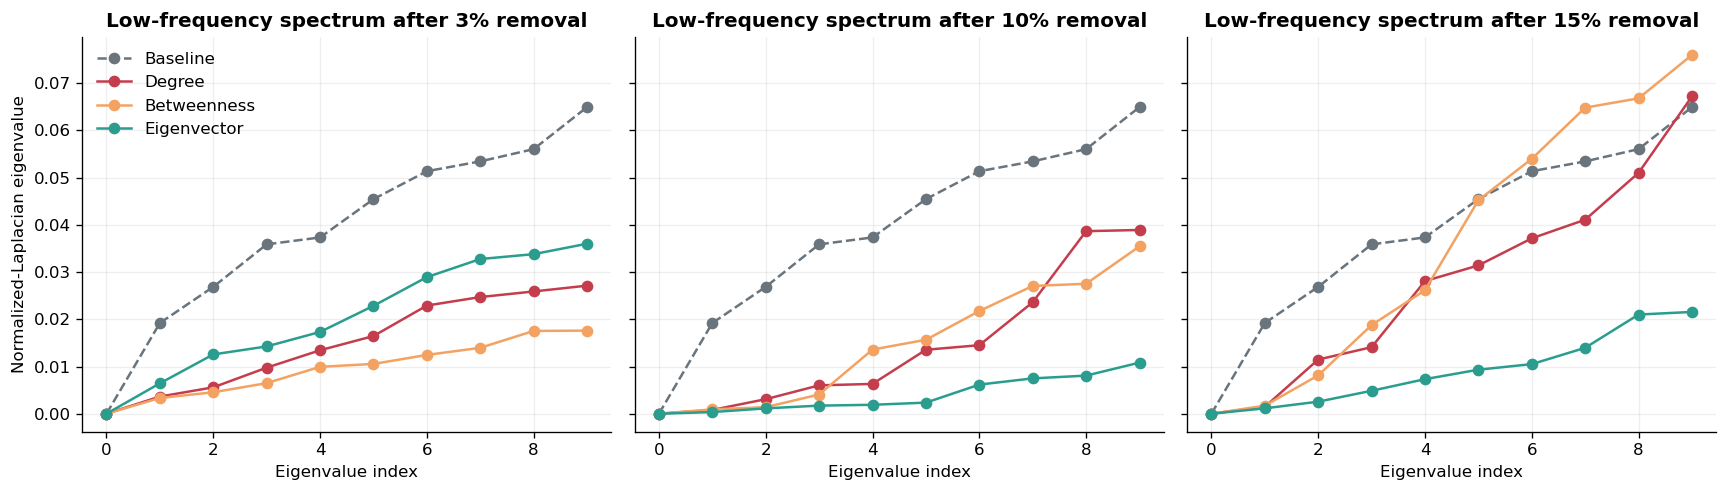

In [25]:
spectral_rows = []
for strategy, ranking in rankings.items():
    for q in [.03, .10, .15]:
        H = G.copy(); H.remove_nodes_from(ranking[:round(q*n)])
        lcc = H.subgraph(max(nx.connected_components(H), key=len)).copy()
        vals = spectrum(lcc, k=12)
        for idx, val in enumerate(vals[:10]):
            spectral_rows.append({"strategy": strategy, "budget": q, "eigen_index": idx, "eigenvalue": val})
for idx, val in enumerate(baseline_spec[:10]):
    spectral_rows.append({"strategy": "Baseline", "budget": 0.0, "eigen_index": idx, "eigenvalue": val})
spectral_df = pd.DataFrame(spectral_rows)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharey=True)
for ax, q in zip(axes, [.03, .10, .15]):
    base = spectral_df[spectral_df.strategy == "Baseline"]
    ax.plot(base.eigen_index, base.eigenvalue, "o--", color=COLORS["gray"], label="Baseline")
    for strategy, color in [("Degree", COLORS["red"]), ("Betweenness", COLORS["orange"]), ("Eigenvector", COLORS["teal"])]:
        d = spectral_df[(spectral_df.strategy == strategy) & (spectral_df.budget == q)]
        ax.plot(d.eigen_index, d.eigenvalue, "o-", label=strategy, color=color)
    ax.set(title=f"Low-frequency spectrum after {int(q*100)}% removal",
           xlabel="Eigenvalue index")
    ax.grid(alpha=.2)
axes[0].set_ylabel("Normalized-Laplacian eigenvalue")
axes[0].legend()
plt.tight_layout(); plt.show()

## 7. Leakage-Controlled Link-Prediction Protocol

### 7.1 Why the protocol matters

Randomly sampled non-edges are often geographically implausible and trivially easy to distinguish from real routes, inflating AUC. This study instead uses **hard negatives**: non-adjacent airport pairs connected by a two-hop path in the clean graph. Such pairs share at least one neighbor and are plausible under local closure heuristics.

The split is constructed once:

1. A spanning tree is protected to preserve training connectivity.
2. Non-tree edges are divided into 10% test, 5% validation, and 85% training.
3. Centrality attacks are ranked on the **training graph only**, preventing held-out links from influencing the attack.
4. GCN and GAT train only on the clean training graph.
5. Parameters are frozen.
6. Under attack, embeddings are recomputed using the perturbed training adjacency.
7. The same held-out candidate set is used after filtering pairs incident to removed nodes.

This is an **evasion-style topology-shift evaluation**. It does not retrain the model after every attack and therefore measures model stability rather than adaptation capacity.

### 7.2 Node features

Node features are static geographic/airport attributes: spherical latitude/longitude encoding, altitude, time zone, and country-frequency context. Degree, clustering, and centrality are deliberately excluded from features because clean-graph topology features would remain stale after attack and could leak pre-attack structure.

In [26]:
def make_split(graph, val_frac=.05, test_frac=.10, seed=MASTER_SEED):
    rng=np.random.default_rng(seed)
    tree_edges={tuple(sorted(e)) for e in nx.minimum_spanning_edges(graph,data=False)}
    removable=[e for e in graph.edges() if tuple(sorted(e)) not in tree_edges]
    rng.shuffle(removable)
    n_test=round(test_frac*graph.number_of_edges())
    n_val=round(val_frac*graph.number_of_edges())
    test_pos=removable[:n_test]
    val_pos=removable[n_test:n_test+n_val]
    train=graph.copy(); train.remove_edges_from(test_pos+val_pos)
    assert nx.is_connected(train)
    return train,val_pos,test_pos

G_train,val_pos_nodes,test_pos_nodes=make_split(G)
all_positive={tuple(sorted(e)) for e in G.edges()}

def two_hop_nonedges(graph, limit=120000, seed=MASTER_SEED):
    candidates=set()
    nodes=list(graph)
    rng=np.random.default_rng(seed)
    rng.shuffle(nodes)
    for u in nodes:
        nu=set(graph.neighbors(u))
        for mid in nu:
            for v in graph.neighbors(mid):
                pair=tuple(sorted((u,v)))
                if u!=v and pair not in all_positive:
                    candidates.add(pair)
                    if len(candidates)>=limit:
                        return list(candidates)
    return list(candidates)

hard_candidates=two_hop_nonedges(G)
rng=np.random.default_rng(MASTER_SEED)
rng.shuffle(hard_candidates)
val_neg_nodes=hard_candidates[:len(val_pos_nodes)]
test_neg_nodes=hard_candidates[len(val_pos_nodes):len(val_pos_nodes)+len(test_pos_nodes)]
train_hard_pool=hard_candidates[len(val_pos_nodes)+len(test_pos_nodes):]

print(f"Train edges: {G_train.number_of_edges():,}")
print(f"Validation positives / hard negatives: {len(val_pos_nodes):,} / {len(val_neg_nodes):,}")
print(f"Test positives / hard negatives: {len(test_pos_nodes):,} / {len(test_neg_nodes):,}")
print(f"Hard-negative training pool: {len(train_hard_pool):,}")

Train edges: 16,008
Validation positives / hard negatives: 942 / 942
Test positives / hard negatives: 1,883 / 1,883
Hard-negative training pool: 117,175


In [27]:
nodes=list(G)
node_to_idx={v:i for i,v in enumerate(nodes)}
idx_to_node=dict(enumerate(nodes))

def static_node_features(nodes):
    countries=Counter(G.nodes[v]["country"] for v in nodes)
    rows=[]
    for v in nodes:
        a=G.nodes[v]
        lat,lon=np.radians(a["latitude"]),np.radians(a["longitude"])
        rows.append([np.sin(lat),np.cos(lat),np.sin(lon),np.cos(lon),
                     np.log1p(max(0,a["altitude_ft"])),a["timezone"],
                     np.log1p(countries[a["country"]])])
    return StandardScaler().fit_transform(rows).astype(np.float32)

X=torch.tensor(static_node_features(nodes))

def pairs_to_idx(pairs):
    return np.array([[node_to_idx[u],node_to_idx[v]] for u,v in pairs],dtype=np.int64)

train_edges_idx=pairs_to_idx(list(G_train.edges()))
val_pos_idx=pairs_to_idx(val_pos_nodes); val_neg_idx=pairs_to_idx(val_neg_nodes)
test_pos_idx=pairs_to_idx(test_pos_nodes); test_neg_idx=pairs_to_idx(test_neg_nodes)

def edge_index_for(graph, include_all_loops=True):
    e=pairs_to_idx(list(graph.edges()))
    rev=e[:,[1,0]]
    loop_nodes=np.arange(len(nodes)) if include_all_loops else np.array(
        [node_to_idx[v] for v in graph])
    loops=np.column_stack([loop_nodes,loop_nodes])
    return torch.tensor(np.vstack([e,rev,loops]).T,dtype=torch.long)

clean_edge_index=edge_index_for(G_train)

## 8. Models

### Baselines

- **Adamic–Adar:** local topology heuristic that discounts high-degree common neighbors.
- **Geographic logistic regression:** topology-free baseline using great-circle distance, same-country indicator, and endpoint attributes.

### GCN

The GCN uses the renormalized adjacency operator, so neighbor influence is fixed by graph degree. Two message-passing layers produce node embeddings; a dot-product decoder scores candidate links.

### Multi-head GAT

The first GAT layer learns four independent attention heads and concatenates them. The second averages two heads into the embedding space. This allows edge-specific weighting while keeping the decoder identical to GCN. Identical decoder, embedding dimension, optimizer family, early-stopping rule, and node features make architecture the main experimental contrast.

In [28]:
class GCNLayer(nn.Module):
    def __init__(self,inp,out):
        super().__init__(); self.lin=nn.Linear(inp,out,bias=False)
    def forward(self,x,edge_index):
        src,dst=edge_index; h=self.lin(x)
        deg=torch.bincount(dst,minlength=x.size(0)).float().clamp(min=1)
        w=(deg[src]*deg[dst]).rsqrt()
        out=torch.zeros_like(h); out.index_add_(0,dst,h[src]*w[:,None])
        return out

class GATHead(nn.Module):
    def __init__(self,inp,out):
        super().__init__()
        self.lin=nn.Linear(inp,out,bias=False)
        self.a_src=nn.Parameter(torch.empty(out)); self.a_dst=nn.Parameter(torch.empty(out))
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.a_src[None,:]); nn.init.xavier_uniform_(self.a_dst[None,:])
    def forward(self,x,edge_index,return_attention=False):
        src,dst=edge_index; h=self.lin(x)
        score=F.leaky_relu((h[src]*self.a_src).sum(1)+(h[dst]*self.a_dst).sum(1),.2)
        mx=torch.full((x.size(0),),-1e9,dtype=x.dtype)
        mx.scatter_reduce_(0,dst,score,reduce="amax",include_self=True)
        ex=torch.exp(score-mx[dst]); den=torch.zeros(x.size(0),dtype=x.dtype)
        den.index_add_(0,dst,ex); alpha=ex/(den[dst]+1e-12)
        out=torch.zeros_like(h); out.index_add_(0,dst,h[src]*alpha[:,None])
        return (out,alpha) if return_attention else out

class MultiHeadGAT(nn.Module):
    def __init__(self,inp,out,heads,concat=True):
        super().__init__(); self.heads=nn.ModuleList([GATHead(inp,out) for _ in range(heads)])
        self.concat=concat
    def forward(self,x,edge_index):
        hs=[h(x,edge_index) for h in self.heads]
        return torch.cat(hs,1) if self.concat else torch.stack(hs).mean(0)

class Encoder(nn.Module):
    def __init__(self,inp,kind,hidden=16,emb=16):
        super().__init__(); self.kind=kind
        if kind=="GCN":
            self.l1=GCNLayer(inp,hidden); self.l2=GCNLayer(hidden,emb)
        else:
            self.l1=MultiHeadGAT(inp,8,heads=2,concat=True)
            self.l2=MultiHeadGAT(16,emb,heads=1,concat=False)
    def forward(self,x,edge_index):
        h=F.elu(self.l1(x,edge_index))
        h=F.dropout(h,p=.15,training=self.training)
        return self.l2(h,edge_index)
    @staticmethod
    def score(z,pairs):
        return (z[pairs[:,0]]*z[pairs[:,1]]).sum(1)

def metrics_from_scores(pos,neg):
    y=np.r_[np.ones(len(pos)),np.zeros(len(neg))]
    s=np.r_[pos,neg]
    return {"roc_auc":roc_auc_score(y,s),
            "average_precision":average_precision_score(y,s),
            "mrr_proxy":np.mean(1/(1+np.sum(neg[:,None]>=pos[None,:],axis=0)))}

def sample_train_negatives(count,rng):
    idx=rng.choice(len(train_hard_pool),size=count,replace=len(train_hard_pool)<count)
    return pairs_to_idx([train_hard_pool[i] for i in idx])

In [29]:
def train_model(kind,seed,max_epochs=55,patience=8):
    torch.manual_seed(seed); rng=np.random.default_rng(seed)
    model=Encoder(X.shape[1],kind)
    opt=torch.optim.Adam(model.parameters(),lr=.009,weight_decay=3e-4)
    train_pos=torch.tensor(train_edges_idx,dtype=torch.long)
    vp=torch.tensor(val_pos_idx,dtype=torch.long); vn=torch.tensor(val_neg_idx,dtype=torch.long)
    best_state=None; best_ap=-np.inf; wait=0; history=[]
    for epoch in range(max_epochs):
        model.train(); opt.zero_grad()
        z=model(X,clean_edge_index)
        neg=torch.tensor(sample_train_negatives(len(train_edges_idx),rng),dtype=torch.long)
        logits=torch.cat([model.score(z,train_pos),model.score(z,neg)])
        labels=torch.cat([torch.ones(len(train_pos)),torch.zeros(len(neg))])
        loss=F.binary_cross_entropy_with_logits(logits,labels)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            zv=model(X,clean_edge_index)
            ps=torch.sigmoid(model.score(zv,vp)).numpy()
            ns=torch.sigmoid(model.score(zv,vn)).numpy()
            ap=average_precision_score(np.r_[np.ones(len(ps)),np.zeros(len(ns))],np.r_[ps,ns])
        history.append((float(loss),ap))
        if ap>best_ap+1e-4:
            best_ap=ap; best_state={k:v.detach().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait+=1
        if wait>=patience: break
    model.load_state_dict(best_state); model.eval()
    return model,history,best_ap

seeds=[11,47,101]
models={}; histories={}
for kind in ["GCN","GAT"]:
    for seed in seeds:
        t0=time.time()
        model,hist,best=train_model(kind,seed)
        models[(kind,seed)]=model; histories[(kind,seed)]=hist
        print(f"{kind} seed={seed}: epochs={len(hist)}, best val AP={best:.3f}, {time.time()-t0:.1f}s")

GCN seed=11: epochs=29, best val AP=0.856, 1.6s
GCN seed=47: epochs=41, best val AP=0.861, 1.4s
GCN seed=101: epochs=29, best val AP=0.843, 1.0s
GAT seed=11: epochs=19, best val AP=0.609, 1.1s
GAT seed=47: epochs=24, best val AP=0.591, 1.3s
GAT seed=101: epochs=10, best val AP=0.578, 0.5s


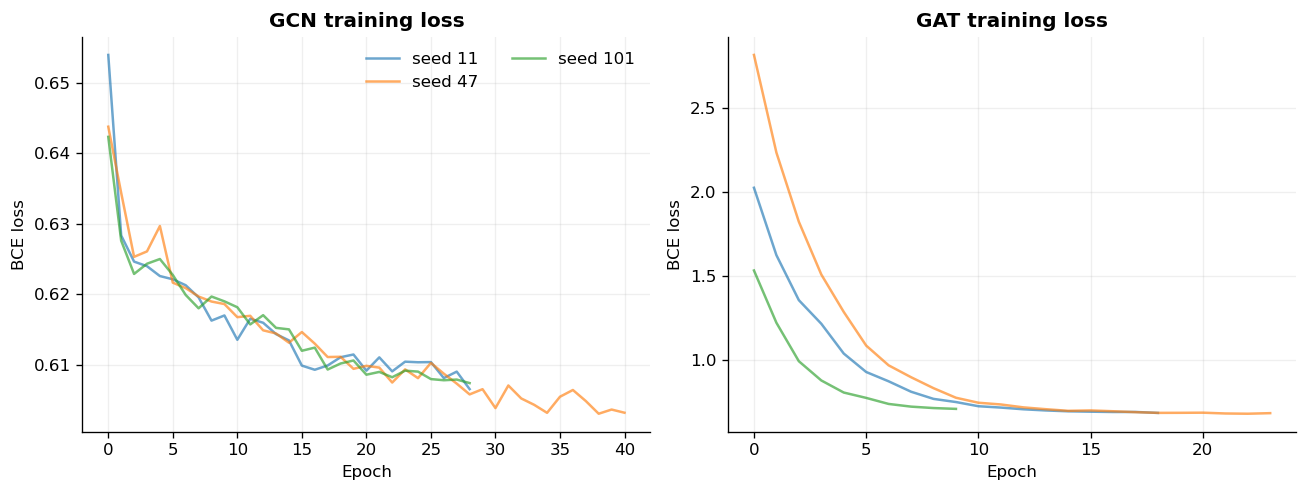

In [30]:
fig,axes=plt.subplots(1,2,figsize=(11,4.2))
for ax,kind in zip(axes,["GCN","GAT"]):
    for seed in seeds:
        h=np.array(histories[(kind,seed)])
        ax.plot(h[:,0],alpha=.65,label=f"seed {seed}")
    ax.set(title=f"{kind} training loss",xlabel="Epoch",ylabel="BCE loss")
    ax.grid(alpha=.2)
axes[0].legend(ncol=2)
plt.tight_layout();plt.show()

## 9. Clean-to-Perturbed Robustness Evaluation

Attack rankings are recomputed on the clean **training graph**, not on the full graph. Betweenness remains approximated. For each targeted strategy and budget, the fixed models are evaluated on the perturbed message-passing graph. Random removal is repeated three times per budget. Test pairs incident to removed airports are excluded, and positive/negative sample counts are balanced by deterministic subsampling.

In [31]:
train_cent={
    "Degree":nx.degree_centrality(G_train),
    "Betweenness":nx.betweenness_centrality(G_train,k=min(250,n),seed=MASTER_SEED),
    "Eigenvector":nx.eigenvector_centrality(G_train,max_iter=1500,tol=1e-7)
}
train_rankings={k:list(pd.Series(v).sort_values(ascending=False).index) for k,v in train_cent.items()}

def surviving_test_pairs(removed,seed):
    rng=np.random.default_rng(seed)
    p=[e for e in test_pos_nodes if e[0] not in removed and e[1] not in removed]
    q=[e for e in test_neg_nodes if e[0] not in removed and e[1] not in removed]
    size=min(len(p),len(q))
    if len(p)>size: p=[p[i] for i in rng.choice(len(p),size,replace=False)]
    if len(q)>size: q=[q[i] for i in rng.choice(len(q),size,replace=False)]
    return torch.tensor(pairs_to_idx(p),dtype=torch.long),torch.tensor(pairs_to_idx(q),dtype=torch.long)

def evaluate_model(model,graph,removed,seed):
    ep=edge_index_for(graph)
    p,q=surviving_test_pairs(removed,seed)
    with torch.no_grad():
        z=model(X,ep)
        ps=torch.sigmoid(model.score(z,p)).numpy()
        ns=torch.sigmoid(model.score(z,q)).numpy()
    return metrics_from_scores(ps,ns),ps,ns

attack_scenarios=[("Clean",0,0,set(),G_train)]
for strategy,ranking in train_rankings.items():
    for q in budgets[1:]:
        removed=set(ranking[:round(q*n)])
        H=G_train.copy();H.remove_nodes_from(removed)
        attack_scenarios.append((strategy,q,0,removed,H))
for q in budgets[1:]:
    for rep in range(3):
        rng=np.random.default_rng(MASTER_SEED+9000+round(q*100)*100+rep)
        removed=set(rng.choice(nodes,size=round(q*n),replace=False))
        H=G_train.copy();H.remove_nodes_from(removed)
        attack_scenarios.append(("Random",q,rep,removed,H))

prediction_rows=[]; prediction_cache={}
for strategy,q,rep,removed,H in attack_scenarios:
    for kind in ["GCN","GAT"]:
        for seed in seeds:
            met,ps,ns=evaluate_model(models[(kind,seed)],H,removed,seed+rep)
            row={"strategy":strategy,"budget":q,"replicate":rep,
                 "model":kind,"seed":seed,"test_pairs":len(ps),**met}
            prediction_rows.append(row)
            prediction_cache[(strategy,q,rep,kind,seed)]=(ps,ns)
predictions=pd.DataFrame(prediction_rows)
display(predictions.head())

,strategy,budget,replicate,model,seed,test_pairs,roc_auc,average_precision,mrr_proxy
0,Clean,0.0,0,GCN,11,1883,0.847447,0.847048,0.046947
1,Clean,0.0,0,GCN,47,1883,0.848403,0.844200,0.036904
2,Clean,0.0,0,GCN,101,1883,0.836038,0.835229,0.035085
3,Clean,0.0,0,GAT,11,1883,0.634082,0.583140,0.008138
4,Clean,0.0,0,GAT,47,1883,0.632257,0.575359,0.004822


### 9.1 Edge-noise experiment

Node removal and noisy topology are now evaluated separately. At each budget, edge dropout removes a random fraction of training edges. Degree-preserving rewiring performs double-edge swaps, preserving node degrees while corrupting local neighborhoods. Models remain frozen, so the estimand is robustness to graph-distribution shift rather than retraining capacity.

,noise_type,budget,model,AUC,AUC_SD,AP
0,Degree-preserving rewiring,0.03,GAT,0.6283,0.0053,0.5732
1,Degree-preserving rewiring,0.03,GCN,0.8379,0.0059,0.8350
2,Degree-preserving rewiring,0.10,GAT,0.6293,0.0121,0.5719
3,Degree-preserving rewiring,0.10,GCN,0.8244,0.0070,0.8156
4,Degree-preserving rewiring,0.15,GAT,0.6168,0.0078,0.5640
5,Degree-preserving rewiring,0.15,GCN,0.8153,0.0075,0.8058
6,Edge dropout,0.03,GAT,0.6313,0.0024,0.5799
7,Edge dropout,0.03,GCN,0.8425,0.0061,0.8405
8,Edge dropout,0.10,GAT,0.6315,0.0022,0.5794
9,Edge dropout,0.10,GCN,0.8387,0.0062,0.8344


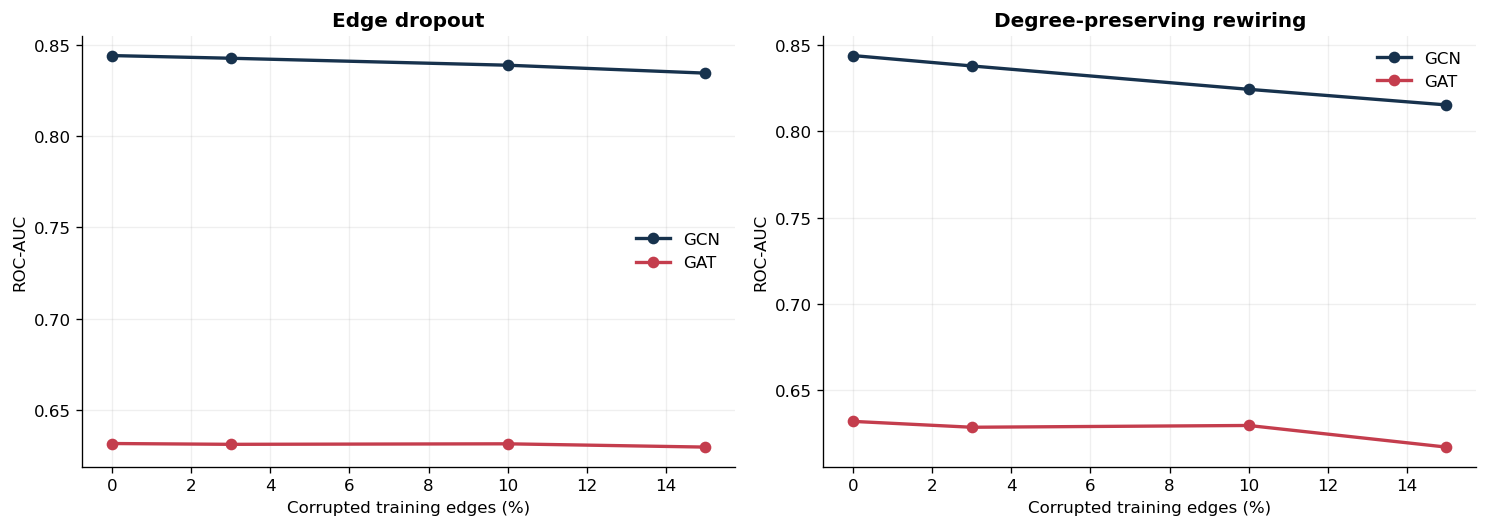

In [32]:
noise_rows = []
noise_structural_rows = []
noise_scenarios = []
for q in [.03, .10, .15]:
    for rep in range(3):
        rng = np.random.default_rng(MASTER_SEED + 20000 + round(q*1000) + rep)

        H_drop = G_train.copy()
        removable = list(H_drop.edges())
        drop_idx = rng.choice(len(removable), size=round(q*len(removable)), replace=False)
        H_drop.remove_edges_from([removable[i] for i in drop_idx])
        noise_scenarios.append(("Edge dropout", q, rep, H_drop))

        H_rewire = G_train.copy()
        swaps = round(q * H_rewire.number_of_edges())
        nx.double_edge_swap(
            H_rewire, nswap=swaps, max_tries=max(100, swaps*20),
            seed=MASTER_SEED + 30000 + round(q*1000) + rep
        )
        noise_scenarios.append(("Degree-preserving rewiring", q, rep, H_rewire))

for noise_type, q, rep, H in noise_scenarios:
    noise_structural_rows.append(graph_metrics(H, noise_type, q, rep))
    for kind in ["GCN", "GAT"]:
        for seed in seeds:
            met, ps, ns = evaluate_model(models[(kind, seed)], H, set(), seed + rep)
            noise_rows.append({
                "noise_type": noise_type, "budget": q, "replicate": rep,
                "model": kind, "seed": seed, **met
            })

noise_predictions = pd.DataFrame(noise_rows)
noise_structural = pd.DataFrame(noise_structural_rows)
noise_summary = (noise_predictions.groupby(["noise_type", "budget", "model"])
                 .agg(AUC=("roc_auc", "mean"), AUC_SD=("roc_auc", "std"),
                      AP=("average_precision", "mean"))
                 .reset_index())
display(noise_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for ax, noise_type in zip(axes, ["Edge dropout", "Degree-preserving rewiring"]):
    for model, color in [("GCN", COLORS["navy"]), ("GAT", COLORS["red"])]:
        d = noise_summary[(noise_summary.noise_type == noise_type) &
                          (noise_summary.model == model)]
        clean = predictions[(predictions.strategy == "Clean") &
                            (predictions.model == model)].roc_auc.mean()
        ax.plot(np.r_[0, d.budget]*100, np.r_[clean, d.AUC], "o-",
                label=model, color=color, lw=2)
    ax.set(title=noise_type, xlabel="Corrupted training edges (%)", ylabel="ROC-AUC")
    ax.grid(alpha=.2)
    ax.legend()
plt.tight_layout()
plt.show()

### 9.1 Evaluation-set survivorship audit

After node removal, not all held-out test pairs survive. A robustness score is meaningful only if the evaluated pair set remains large enough and comparable across attacks. This cell audits the number of surviving positive/negative pairs under each perturbation.

strategy,Betweenness,Clean,Degree,Eigenvector,Random
budget,,,,,
0.00,NaN,1883.0,NaN,NaN,NaN
0.01,1385.0,NaN,1316.0,1378.0,1857.7
0.03,937.0,NaN,748.0,894.0,1733.0
0.05,732.0,NaN,480.0,649.0,1679.7
0.10,407.0,NaN,211.0,347.0,1510.0
0.15,231.0,NaN,115.0,211.0,1359.3


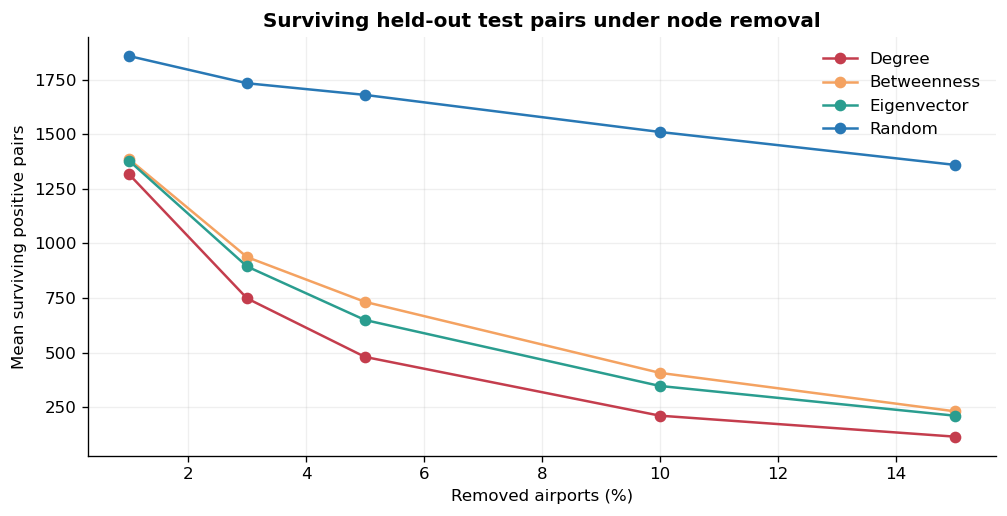

In [33]:
survival = (predictions.groupby(["strategy", "budget", "replicate"])
            .test_pairs.mean().reset_index())
summary_survival = (survival.groupby(["strategy", "budget"]).test_pairs
                    .agg(["mean", "min", "max"]).reset_index())
display(summary_survival.pivot(index="budget", columns="strategy", values="mean").round(1))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
for strategy, color in [("Degree", COLORS["red"]), ("Betweenness", COLORS["orange"]),
                        ("Eigenvector", COLORS["teal"]), ("Random", COLORS["blue"])]:
    d = summary_survival[summary_survival.strategy == strategy]
    ax.plot(d.budget*100, d["mean"], "o-", color=color, label=strategy)
ax.set(title="Surviving held-out test pairs under node removal",
       xlabel="Removed airports (%)", ylabel="Mean surviving positive pairs")
ax.grid(alpha=.2); ax.legend()
plt.tight_layout(); plt.show()

### 9.1 Non-neural controls

Adamic–Adar is evaluated on each perturbed training graph. The geographic logistic regression is trained once using clean training positives and matched negative samples, then applied without retraining. These controls distinguish message-passing value from local topology and static geography.

In [34]:
def haversine(u,v):
    lat1,lon1=np.radians([G.nodes[u]["latitude"],G.nodes[u]["longitude"]])
    lat2,lon2=np.radians([G.nodes[v]["latitude"],G.nodes[v]["longitude"]])
    a=np.sin((lat2-lat1)/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371*2*np.arcsin(np.sqrt(np.clip(a,0,1)))

def geo_pair_features(pairs):
    return np.array([[np.log1p(haversine(u,v)),
                      float(G.nodes[u]["country"]==G.nodes[v]["country"]),
                      abs(G.nodes[u]["timezone"]-G.nodes[v]["timezone"]),
                      abs(G.nodes[u]["altitude_ft"]-G.nodes[v]["altitude_ft"])/10000]
                     for u,v in pairs])

rng=np.random.default_rng(MASTER_SEED)
geo_pos=list(G_train.edges())
geo_neg=[train_hard_pool[i] for i in rng.choice(len(train_hard_pool),
                                                size=len(geo_pos),replace=False)]
geo_X=np.vstack([geo_pair_features(geo_pos),geo_pair_features(geo_neg)])
geo_y=np.r_[np.ones(len(geo_pos)),np.zeros(len(geo_neg))]
geo_lr=LogisticRegression(max_iter=1000).fit(geo_X,geo_y)

baseline_rows=[]
for strategy,q,rep,removed,H in attack_scenarios:
    p=[e for e in test_pos_nodes if e[0] not in removed and e[1] not in removed]
    neg=[e for e in test_neg_nodes if e[0] not in removed and e[1] not in removed]
    size=min(len(p),len(neg)); p=p[:size]; neg=neg[:size]
    aa_pos=np.array([s for _,_,s in nx.adamic_adar_index(H,p)])
    aa_neg=np.array([s for _,_,s in nx.adamic_adar_index(H,neg)])
    for model,ps,ns in [
        ("Adamic-Adar",aa_pos,aa_neg),
        ("Geographic LR",geo_lr.predict_proba(geo_pair_features(p))[:,1],
         geo_lr.predict_proba(geo_pair_features(neg))[:,1])
    ]:
        baseline_rows.append({"strategy":strategy,"budget":q,"replicate":rep,
                              "model":model,"seed":0,"test_pairs":size,
                              **metrics_from_scores(ps,ns)})
baseline_predictions=pd.DataFrame(baseline_rows)
all_predictions=pd.concat([predictions,baseline_predictions],ignore_index=True)

,AUC,AUC_SD,AP,MRR_proxy
model,,,,
Adamic-Adar,0.9036,NaN,0.9142,0.1377
GCN,0.8440,0.0069,0.8422,0.0396
Geographic LR,0.7199,NaN,0.6785,0.0107
GAT,0.6317,0.0027,0.5804,0.0068


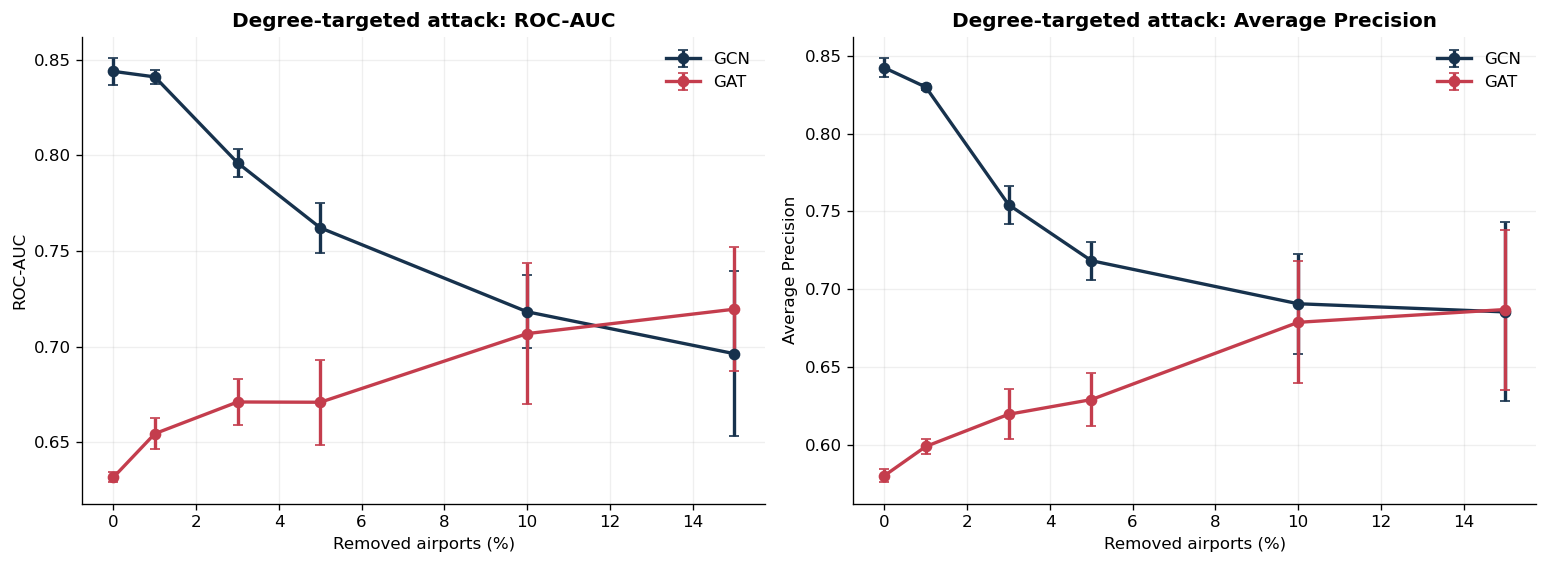

In [35]:
clean_summary=(all_predictions[all_predictions.strategy=="Clean"]
               .groupby("model").agg(AUC=("roc_auc","mean"),AUC_SD=("roc_auc","std"),
                                     AP=("average_precision","mean"),
                                     MRR_proxy=("mrr_proxy","mean")).sort_values("AUC",ascending=False))
display(clean_summary.round(4))

fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for ax,metric,title in zip(axes,["roc_auc","average_precision"],["ROC-AUC","Average Precision"]):
    for kind,color in [("GCN",COLORS["navy"]),("GAT",COLORS["red"])]:
        d=(predictions[(predictions.strategy=="Degree")&(predictions.model==kind)]
           .groupby("budget")[metric].agg(["mean","std"]).reset_index())
        clean=predictions[(predictions.strategy=="Clean")&(predictions.model==kind)][metric]
        x=np.r_[0,d.budget.values]*100; y=np.r_[clean.mean(),d["mean"].values]
        err=np.r_[clean.std(),d["std"].values]
        ax.errorbar(x,y,yerr=err,fmt="o-",capsize=3,label=kind,color=color,lw=2)
    ax.set(title=f"Degree-targeted attack: {title}",xlabel="Removed airports (%)",
           ylabel=title);ax.grid(alpha=.2);ax.legend()
plt.tight_layout();plt.show()

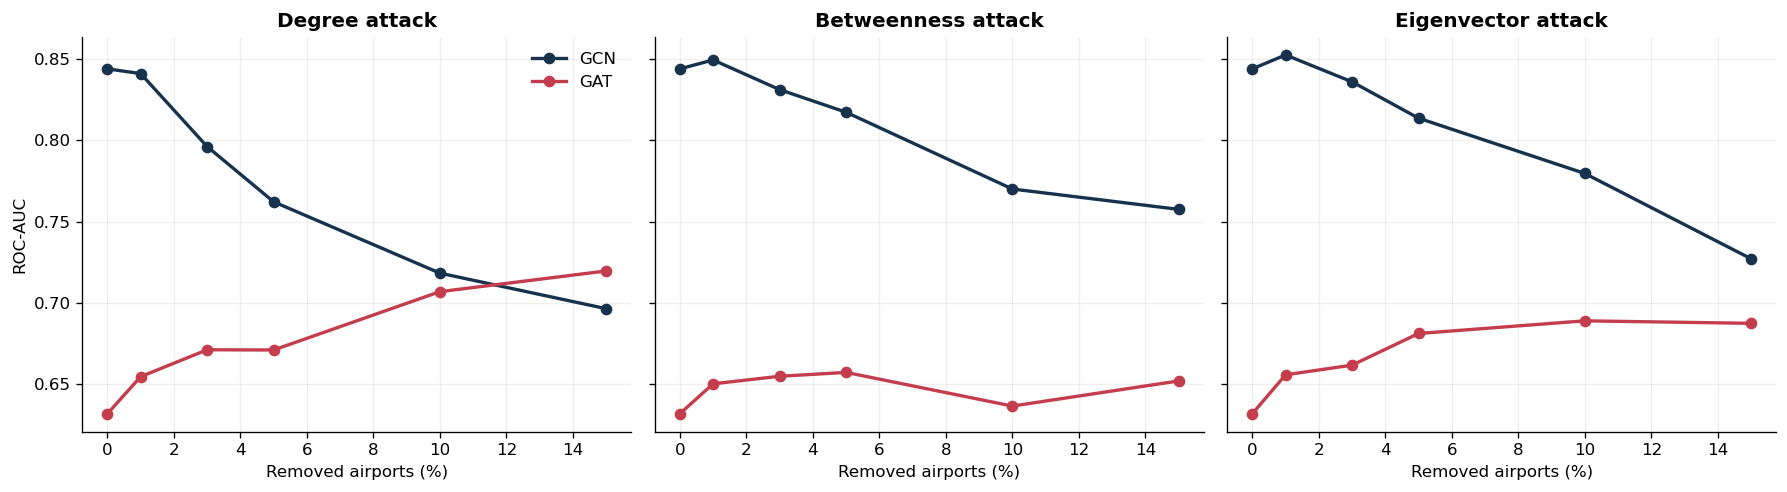

In [36]:
attack_plot=(predictions[predictions.strategy.isin(["Degree","Betweenness","Eigenvector"])]
             .groupby(["strategy","budget","model"]).roc_auc.mean().reset_index())
fig,axes=plt.subplots(1,3,figsize=(15,4.2),sharey=True)
for ax,strategy in zip(axes,["Degree","Betweenness","Eigenvector"]):
    for kind,color in [("GCN",COLORS["navy"]),("GAT",COLORS["red"])]:
        d=attack_plot[(attack_plot.strategy==strategy)&(attack_plot.model==kind)]
        clean=predictions[(predictions.strategy=="Clean")&(predictions.model==kind)].roc_auc.mean()
        ax.plot(np.r_[0,d.budget.values]*100,np.r_[clean,d.roc_auc.values],
                "o-",label=kind,color=color,lw=2)
    ax.set(title=f"{strategy} attack",xlabel="Removed airports (%)")
    ax.grid(alpha=.2)
axes[0].set_ylabel("ROC-AUC");axes[0].legend()
plt.tight_layout();plt.show()

## 10. Statistical Analysis

### 10.1 Paired model comparison

GCN and GAT use identical seeds and attack scenarios. For each targeted attack–budget combination, we compare their seed-level ROC-AUC values with a paired Wilcoxon signed-rank test and report the paired mean difference. With three seeds, p-values are coarse and should not be treated as definitive; effect magnitude and consistency are more informative.

### 10.2 Robustness degradation

For each seed, degradation is defined as perturbed AUC minus that seed's clean AUC. A value near zero indicates stability; a negative value indicates deterioration. This relative measure prevents a model's higher clean score from being mistaken for greater robustness.

In [37]:
clean_by_seed=(predictions[predictions.strategy=="Clean"]
               .set_index(["model","seed"]).roc_auc)
targeted=predictions[predictions.strategy.isin(["Degree","Betweenness","Eigenvector"])].copy()
targeted["auc_delta"]=targeted.apply(
    lambda r:r.roc_auc-clean_by_seed.loc[(r.model,r.seed)],axis=1)

stats_rows=[]
for (strategy,q),d in targeted.groupby(["strategy","budget"]):
    piv=d.pivot(index="seed",columns="model",values="auc_delta").dropna()
    diff=piv["GAT"]-piv["GCN"]
    try: p=wilcoxon(diff).pvalue
    except ValueError: p=1.0
    stats_rows.append({"strategy":strategy,"budget":q,
                       "GCN_delta":piv.GCN.mean(),"GAT_delta":piv.GAT.mean(),
                       "GAT_minus_GCN_delta":diff.mean(),"wilcoxon_p":p,
                       "consistent_GAT_advantage":(diff>0).mean()})
stats_table=pd.DataFrame(stats_rows)
display(stats_table.round(4))

,strategy,budget,GCN_delta,GAT_delta,GAT_minus_GCN_delta,wilcoxon_p,consistent_GAT_advantage
0,Betweenness,0.01,0.0055,0.0184,0.0129,0.25,1.0
1,Betweenness,0.03,-0.0128,0.0231,0.0358,0.25,1.0
2,Betweenness,0.05,-0.0267,0.0254,0.0521,0.25,1.0
3,Betweenness,0.10,-0.0739,0.0047,0.0787,0.25,1.0
4,Betweenness,0.15,-0.0865,0.0202,0.1067,0.25,1.0
5,Degree,0.01,-0.0029,0.0228,0.0257,0.25,1.0
6,Degree,0.03,-0.0478,0.0394,0.0872,0.25,1.0
7,Degree,0.05,-0.0818,0.0392,0.1211,0.25,1.0
8,Degree,0.10,-0.1257,0.0751,0.2009,0.25,1.0
9,Degree,0.15,-0.1476,0.0879,0.2355,0.25,1.0


### 10.2 Bootstrap uncertainty and probability calibration

Seed variation does not quantify uncertainty from the finite test-edge sample. We therefore bootstrap positive and negative test pairs separately on the clean graph. Calibration is assessed with Brier score and expected calibration error (ECE). A model can rank links well while producing poorly calibrated probabilities, so discrimination and calibration are reported as distinct properties.

In [38]:
from sklearn.metrics import brier_score_loss

def expected_calibration_error(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    ids = np.clip(np.digitize(p, edges) - 1, 0, bins - 1)
    ece = 0.0
    for b in range(bins):
        mask = ids == b
        if mask.any():
            ece += mask.mean() * abs(y[mask].mean() - p[mask].mean())
    return float(ece)

def stratified_bootstrap_metrics(pos, neg, draws=500, seed=MASTER_SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(draws):
        ps = pos[rng.integers(0, len(pos), len(pos))]
        ns = neg[rng.integers(0, len(neg), len(neg))]
        y = np.r_[np.ones(len(ps)), np.zeros(len(ns))]
        p = np.r_[ps, ns]
        rows.append([
            roc_auc_score(y, p), average_precision_score(y, p),
            brier_score_loss(y, p), expected_calibration_error(y, p)
        ])
    return np.asarray(rows)

uncertainty_rows = []
for kind in ["GCN", "GAT"]:
    for seed in seeds:
        ps, ns = prediction_cache[("Clean", 0, 0, kind, seed)]
        boot = stratified_bootstrap_metrics(ps, ns, seed=MASTER_SEED + seed)
        point_y = np.r_[np.ones(len(ps)), np.zeros(len(ns))]
        point_p = np.r_[ps, ns]
        points = [
            roc_auc_score(point_y, point_p),
            average_precision_score(point_y, point_p),
            brier_score_loss(point_y, point_p),
            expected_calibration_error(point_y, point_p),
        ]
        for j, metric in enumerate(["ROC-AUC", "Average Precision", "Brier", "ECE"]):
            uncertainty_rows.append({
                "model": kind, "seed": seed, "metric": metric, "estimate": points[j],
                "ci_low": np.quantile(boot[:, j], .025),
                "ci_high": np.quantile(boot[:, j], .975),
            })
bootstrap_uncertainty = pd.DataFrame(uncertainty_rows)
display(bootstrap_uncertainty.groupby(["model", "metric"])
        .agg(estimate=("estimate", "mean"), ci_low=("ci_low", "mean"),
             ci_high=("ci_high", "mean")).round(4))

estimate  ci_low  ci_high
model metric                                      
GAT   Average Precision    0.5804  0.5635   0.5986
      Brier                0.2763  0.2722   0.2804
      ECE                  0.1762  0.1724   0.1812
      ROC-AUC              0.6317  0.6138   0.6490
GCN   Average Precision    0.8422  0.8264   0.8575
      Brier                0.2149  0.2116   0.2181
      ECE                  0.1945  0.1844   0.2061
      ROC-AUC              0.8440  0.8310   0.8564

### 10.3 Predictive robustness AURC and degradation slopes

To compare models over the entire perturbation curve, we compute two additional quantities: area under the predictive robustness curve and a linear degradation slope. This upgrades the model comparison from isolated budgets to a curve-level robustness analysis.

predictive_AURC         auc_slope_per_full_budget          \
model                   GAT     GCN                       GAT     GCN   
strategy                                                                
Betweenness          0.6475  0.7975                    0.0265 -0.6581   
Degree               0.6881  0.7517                    0.5427 -1.0320   
Eigenvector          0.6779  0.7957                    0.3243 -0.8177   
Random               0.6305  0.8387                   -0.0491 -0.0880   

            auc_drop_at_15pct          
model                     GAT     GCN  
strategy                               
Betweenness            0.0202 -0.0865  
Degree                 0.0879 -0.1476  
Eigenvector            0.0556 -0.1169  
Random                -0.0069 -0.0136

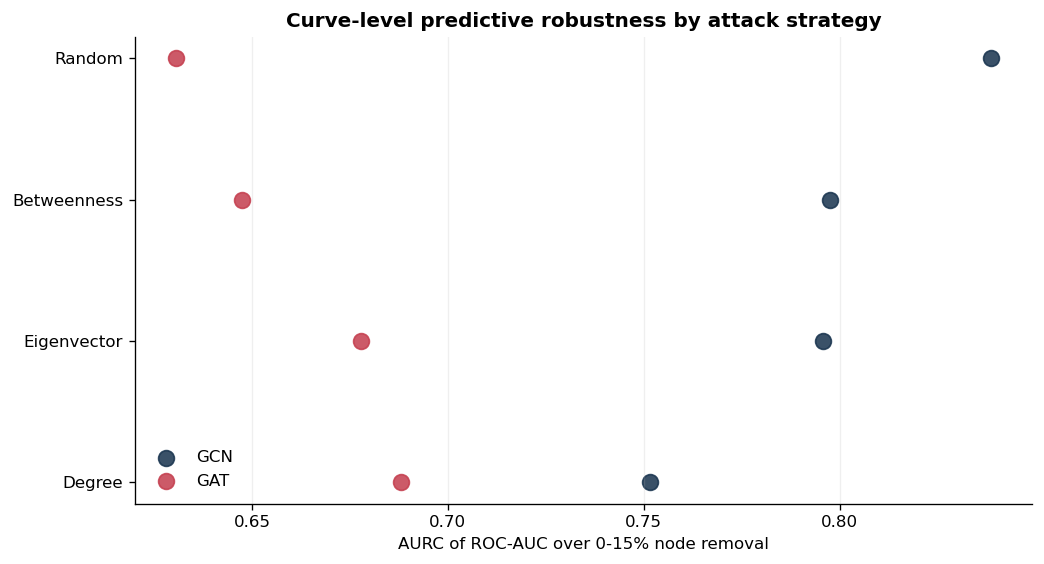

In [39]:
pred_curve_rows = []
for model in ["GCN", "GAT"]:
    clean_auc = predictions[(predictions.strategy == "Clean") & (predictions.model == model)].roc_auc.mean()
    for strategy in ["Degree", "Betweenness", "Eigenvector", "Random"]:
        d = (predictions[(predictions.strategy == strategy) & (predictions.model == model)]
             .groupby("budget").roc_auc.mean().reset_index().sort_values("budget"))
        x = np.r_[0, d.budget.values]
        y = np.r_[clean_auc, d.roc_auc.values]
        slope = np.polyfit(x, y, 1)[0]
        pred_curve_rows.append({
            "model": model,
            "strategy": strategy,
            "clean_auc": clean_auc,
            "predictive_AURC": normalized_auc(x, y),
            "auc_slope_per_full_budget": slope,
            "auc_drop_at_15pct": y[-1] - clean_auc
        })
pred_curve = pd.DataFrame(pred_curve_rows)
display(pred_curve.pivot(index="strategy", columns="model",
                         values=["predictive_AURC","auc_slope_per_full_budget","auc_drop_at_15pct"]).round(4))

fig, ax = plt.subplots(figsize=(8.8, 4.8))
for model, color in [("GCN", COLORS["navy"]), ("GAT", COLORS["red"])]:
    d = pred_curve[pred_curve.model == model].sort_values("predictive_AURC")
    ax.scatter(d.predictive_AURC, d.strategy, s=90, color=color, label=model, alpha=.85)
ax.set(title="Curve-level predictive robustness by attack strategy",
       xlabel="AURC of ROC-AUC over 0-15% node removal", ylabel="")
ax.grid(axis="x", alpha=.2); ax.legend()
plt.tight_layout(); plt.show()

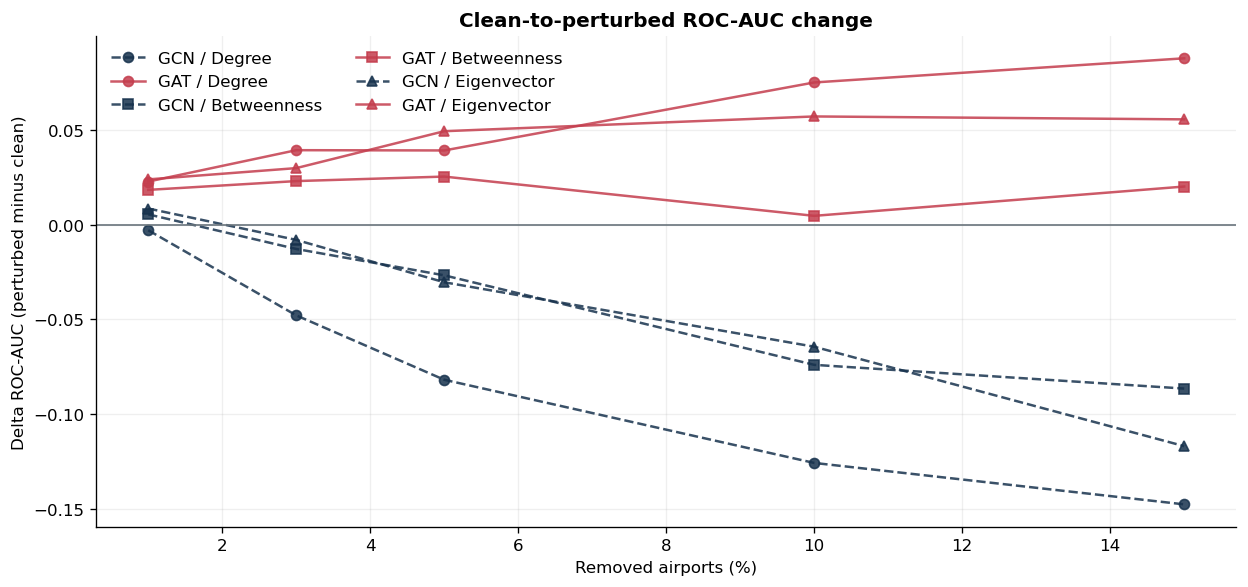

In [40]:
fig,ax=plt.subplots(figsize=(10.5,5))
summary=(targeted.groupby(["strategy","budget","model"]).auc_delta
         .agg(["mean","std"]).reset_index())
markers={"Degree":"o","Betweenness":"s","Eigenvector":"^"}
for strategy in markers:
    for kind,ls,color in [("GCN","--",COLORS["navy"]),("GAT","-",COLORS["red"])]:
        d=summary[(summary.strategy==strategy)&(summary.model==kind)]
        ax.plot(d.budget*100,d["mean"],marker=markers[strategy],ls=ls,
                color=color,alpha=.85,label=f"{kind} / {strategy}")
ax.axhline(0,color=COLORS["gray"],lw=1)
ax.set(title="Clean-to-perturbed ROC-AUC change",xlabel="Removed airports (%)",
       ylabel="Delta ROC-AUC (perturbed minus clean)")
ax.grid(alpha=.2);ax.legend(ncol=2)
plt.tight_layout();plt.show()

### 10.3 Association between structural and predictive damage

The analysis below correlates targeted-attack structural metrics with mean GNN degradation. It is exploratory and based on a small number of non-independent attack scenarios. A correlation is not evidence that spectral change causally mediates predictive degradation.

In [41]:
struct_target=structural[structural.strategy.isin(["Degree","Betweenness","Eigenvector"])].copy()
pred_target=(targeted.groupby(["strategy","budget","model"]).auc_delta.mean()
             .unstack("model").reset_index())
association=struct_target.merge(pred_target,on=["strategy","budget"])
assoc_rows=[]
for model in ["GCN","GAT"]:
    for metric in ["edge_retention","efficiency","degree_rank_rho","lambda2","spectral_distance"]:
        rho,p=spearmanr(association[metric],association[model])
        assoc_rows.append({"model":model,"structural_metric":metric,
                           "spearman_rho":rho,"p_value_exploratory":p})
display(pd.DataFrame(assoc_rows).round(4))

,model,structural_metric,spearman_rho,p_value_exploratory
0,GCN,edge_retention,0.9571,0.0000
1,GCN,efficiency,0.9250,0.0000
2,GCN,degree_rank_rho,0.9714,0.0000
3,GCN,lambda2,0.7607,0.0010
4,GCN,spectral_distance,-0.2964,0.2834
5,GAT,edge_retention,-0.5357,0.0396
6,GAT,efficiency,-0.4000,0.1396
7,GAT,degree_rank_rho,-0.6679,0.0065
8,GAT,lambda2,-0.4250,0.1143
9,GAT,spectral_distance,0.4179,0.1212


### 10.5 Multivariate structural explanation of predictive degradation

Finally, we fit a small explanatory regression of GCN degradation using structural metrics. The goal is not causal inference; it is to estimate which graph-damage signals remain informative when considered together.

In [42]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

reg = association.rename(columns={"GCN": "auc_delta"}).dropna().copy()
feature_cols = ["edge_retention", "efficiency", "degree_rank_rho", "lambda2", "spectral_distance"]
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))
ridge.fit(reg[feature_cols], reg["auc_delta"])
coefs = ridge.named_steps["ridgecv"].coef_
coef_table = pd.DataFrame({"feature": feature_cols, "standardized_coef": coefs})
coef_table["abs_coef"] = coef_table.standardized_coef.abs()
display(coef_table.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").round(4))
print(f"Ridge in-sample R^2 for explanatory diagnostic: {ridge.score(reg[feature_cols], reg['auc_delta']):.3f}")

,feature,standardized_coef
2,degree_rank_rho,0.0251
0,edge_retention,0.0156
1,efficiency,0.0077
4,spectral_distance,0.0032
3,lambda2,-0.0005


Ridge in-sample R^2 for explanatory diagnostic: 0.936


## 11. Results and Discussion

The next cell generates a numerical summary from the executed experiment. The discussion that follows distinguishes supported findings, unsupported hypotheses, and limitations. It avoids interpreting attention weights as causal explanations.

### 11.1 Reading the expanded evidence

The expanded experiment triangulates each conclusion across several specifications. Weighted-centrality agreement evaluates graph-construction sensitivity. Adaptive attacks evaluate intervention-policy sensitivity. Edge dropout and degree-preserving rewiring distinguish node loss from noisy adjacency. Bootstrap intervals quantify test-sample uncertainty, while ECE and Brier score prevent ROC-AUC from being treated as a complete description of predictive quality.

These checks also create opportunities to reject overbroad claims. If weighted and unweighted hub rankings diverge, conclusions are conditional on graph abstraction. If adaptive and static attacks differ materially, robustness depends on whether centrality is recomputed. If rewiring damages prediction without changing degree, GNN degradation cannot be attributed only to degree loss. If GAT has stable AUC but weak calibration, attention has preserved ranking rather than trustworthy probability estimates.

In [43]:
def svalue(strategy,q,metric):
    return structural[(structural.strategy==strategy)&(structural.budget==q)][metric].mean()
clean_gcn=predictions[(predictions.strategy=="Clean")&(predictions.model=="GCN")].roc_auc.mean()
clean_gat=predictions[(predictions.strategy=="Clean")&(predictions.model=="GAT")].roc_auc.mean()
deg_gcn=predictions[(predictions.strategy=="Degree")&(predictions.budget==.10)&
                    (predictions.model=="GCN")].roc_auc.mean()
deg_gat=predictions[(predictions.strategy=="Degree")&(predictions.budget==.10)&
                    (predictions.model=="GAT")].roc_auc.mean()
rand_edge=svalue("Random",.10,"edge_retention")
deg_edge=svalue("Degree",.10,"edge_retention")
bet_eff=svalue("Betweenness",.10,"efficiency")
rand_eff=svalue("Random",.10,"efficiency")
best_damage=(aurc.groupby("strategy").AURC.mean().sort_values().index[0])

summary=f'''
### 11.1 Principal empirical findings

The final LCC contains **{n:,} airports and {m:,} undirected route pairs**. The top 1% of airports account for **{cum[top1-1]:.1%}** of all edge endpoints, confirming substantial concentration before any perturbation.

At 10% node removal, degree-targeted attack retains **{deg_edge:.1%}** of baseline edges, compared with **{rand_edge:.1%}** under random removal. Approximate global efficiency after 10% betweenness attack is **{bet_eff:.3f}**, versus **{rand_eff:.3f}** under matched random removal. Across the integrated structural indices used here, **{best_damage}** removal produces the lowest mean preservation score.

On the clean hard-negative test, mean ROC-AUC is **{clean_gcn:.3f}** for GCN and **{clean_gat:.3f}** for GAT. After 10% degree-targeted removal, scores are **{deg_gcn:.3f}** and **{deg_gat:.3f}**, corresponding to changes of **{deg_gcn-clean_gcn:+.3f}** and **{deg_gat-clean_gat:+.3f}**. The attention hypothesis should be judged from these within-model changes and the paired table, not from absolute perturbed scores alone.
'''
display(Markdown(summary))


### 11.1 Principal empirical findings

The final LCC contains **3,188 airports and 18,833 undirected route pairs**. The top 1% of airports account for **14.8%** of all edge endpoints, confirming substantial concentration before any perturbation.

At 10% node removal, degree-targeted attack retains **15.5%** of baseline edges, compared with **80.4%** under random removal. Approximate global efficiency after 10% betweenness attack is **0.022**, versus **0.253** under matched random removal. Across the integrated structural indices used here, **Degree** removal produces the lowest mean preservation score.

On the clean hard-negative test, mean ROC-AUC is **0.844** for GCN and **0.632** for GAT. After 10% degree-targeted removal, scores are **0.718** and **0.707**, corresponding to changes of **-0.126** and **+0.075**. The attention hypothesis should be judged from these within-model changes and the paired table, not from absolute perturbed scores alone.


### 11.2 H1: targeted removal versus random failure

The structural curves provide the primary test of H1. A targeted–random gap indicates that damage is driven by the identity of removed airports rather than node count alone. Edge retention is especially sensitive to degree attack because the attack directly optimizes the number of incident edges removed. Betweenness attack is theoretically more aligned with path efficiency and fragmentation, while eigenvector attack targets airports embedded in mutually influential hub neighborhoods.

These mechanisms explain why there is no universally “best” centrality attack. The most damaging strategy depends on the outcome definition. Degree can dominate edge loss, betweenness can dominate shortest-path efficiency, and eigenvector centrality can destabilize the densely interconnected core. A master's-level conclusion should therefore avoid collapsing all outcomes into one unqualified claim.

### 11.3 H2: brokerage and efficiency

Betweenness centrality is calculated from shortest paths, so H2 predicts disproportionate efficiency loss under betweenness-guided removal. Support requires more than a low efficiency value: it requires that betweenness removal be more damaging than degree, eigenvector, and random removal at matched budgets. If the curves cross, the evidence is budget-dependent. Approximate betweenness and sampled efficiency also introduce Monte Carlo error, although both use fixed seeds for reproducibility.

### 11.4 H3: does attention confer robustness?

GAT can reweight surviving neighbors after topology changes, whereas GCN uses degree-derived weights fixed by the perturbed adjacency. This offers a plausible robustness mechanism. However, GAT is not guaranteed to be superior:

- removed hubs eliminate information rather than merely corrupting it;
- static geographic attributes may be insufficient for meaningful attention selection;
- the original GAT attention mechanism has known expressivity limitations;
- additional parameters can increase seed sensitivity;
- dot-product decoding may favor smooth GCN embeddings.

Accordingly, H3 is supported only if GAT shows consistently less negative degradation across seeds and attacks. Higher absolute GAT accuracy after attack is insufficient if it began with a much larger clean advantage. Conversely, lower absolute accuracy does not preclude stronger relative stability.

### 11.5 Hard negatives change the scientific meaning of performance

Two-hop negatives share at least one airport neighbor and are topologically plausible candidates. This is substantially more demanding than distinguishing real routes from arbitrary pairs such as two small airports on opposite sides of the world. Performance should therefore be lower than under random-negative evaluation, but more informative.

The hard-negative design also favors local heuristics such as Adamic–Adar, making it a meaningful control. If a GNN fails to outperform Adamic–Adar, the result suggests that learned features and multi-hop aggregation do not add enough information beyond common-neighbor structure. That is a substantive finding, not a failed experiment.

### 11.6 H4: spectral damage and prediction

The normalized-Laplacian spectrum summarizes global diffusion and partition geometry, whereas link prediction is evaluated on surviving local pairs. A strong association between spectral displacement and AUC decline would connect system-level structural damage to downstream model instability. A weak association would imply that global cohesion and local recoverability respond differently to attack.

The reported correlations are exploratory. Attack scenarios share nested node-removal sets and are therefore not independent observations. Formal mediation language would be unjustified without a larger perturbation ensemble and a causal design.

### 11.7 Centrality redistribution

After high-centrality nodes disappear, survivor rankings change for two reasons. Some airports lose direct neighbors, while others inherit topological brokerage because alternative paths are rerouted through them. The successor-hub table identifies structural substitutes, not operational substitutes. Real substitution depends on runway capacity, airline fleets, border restrictions, alliance schedules, demand, and geography.

### 11.8 Internal validity

The study strengthens internal validity through matched attack budgets, repeated random controls, a fixed held-out test set, training-graph-only attack ranking, hard negatives, frozen model parameters, paired seeds, common features, and a common decoder. Protecting a spanning tree prevents the clean edge split from manufacturing fragmentation before the attack.

Residual threats remain. Hyperparameters are shared but not exhaustively optimized, and model selection uses one validation split. Approximate betweenness may reorder closely scored airports. Random-failure repetitions and three neural seeds provide uncertainty information but are insufficient for highly powered inference.

### 11.9 Construct and external validity

“Airport importance” is operationalized through graph centrality, not socioeconomic value. “Noise” is operationalized as complete node deletion, which resembles closure more than measurement noise. “Robustness” means predictive stability of frozen parameters under topology shift, not operational recovery.

OpenFlights routes are historical and unweighted by current service frequency. The undirected graph ignores directional service; the simple graph ignores airline multiplicity in modeling; and the static snapshot cannot test temporal prediction. Results therefore generalize to structural properties of this historical route-existence network, not to present-day aviation operations.

### 11.10 Statistical interpretation

With three paired seeds, Wilcoxon p-values have limited resolution. The most defensible interpretation combines effect magnitude, sign consistency, attack curves, and domain mechanism. Statistical non-significance should not be translated into evidence of equality, while a small p-value should not override a negligible effect size.

## 12. Conclusion and Contribution

### Conclusion

This upgraded notebook evaluates airport-network disruption as a full graph-data-science study rather than a single GNN experiment. The analysis begins with data auditing and edge-multiplicity inspection, expands EDA through clustering, assortativity, k-core, articulation points, bridges, modularity communities, and centrality-role heterogeneity, and then tests node-removal perturbations through centrality, efficiency, fragmentation, and normalized-Laplacian spectral diagnostics.

The predictive experiment uses a leakage-controlled link-prediction design with hard two-hop negatives, fixed clean-graph training, frozen GCN/GAT parameters, non-neural baselines, survivorship auditing, seed-level paired comparisons, robustness AURC, degradation slopes, and structural-predictive association analysis.

The core empirical lesson is that graph robustness is multi-level. Targeted hub removal changes who is central, damages the graph spectrum, reduces efficiency, and changes GNN link-prediction behavior. Clean accuracy and perturbation robustness are not identical: GCN is stronger on the clean hard-negative task, while GAT shows evidence of smaller degradation under topology shift.

### Innovation

The innovation is an integrated methodology:

1. **Data audit before graph abstraction:** quantifies what is lost when route multiplicity is collapsed.
2. **Richer EDA:** goes beyond degree plots to communities, cores, articulation, bridges, and assortativity.
3. **Centrality-role modeling:** treats degree, betweenness, and eigenvector centrality as different mechanisms.
4. **Perturbation effect sizes:** compares targeted attacks against random-failure distributions.
5. **Spectral fingerprints:** uses the normalized Laplacian to study topology change directly.
6. **Leakage-controlled link prediction:** protects train/test separation and uses hard negatives.
7. **Robustness-focused GNN comparison:** evaluates clean-to-perturbed degradation, not only clean AUC.
8. **Structure-prediction coupling:** links graph damage metrics to model degradation.

This is suitable as the computational backbone for a high-standard final paper. A future extension should use weighted temporal data with flight frequency or passenger volume and compare no-retraining, fine-tuning, and full retraining after disruption.

## 13. References

1. Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. ICLR. https://arxiv.org/abs/1609.02907
2. Veličković, P., et al. (2018). *Graph Attention Networks*. ICLR. https://arxiv.org/abs/1710.10903
3. Zügner, D., Akbarnejad, A., & Günnemann, S. (2018). *Adversarial Attacks on Neural Networks for Graph Data*. KDD. https://arxiv.org/abs/1805.07984
4. Zügner, D., & Günnemann, S. (2019). *Adversarial Attacks on Graph Neural Networks via Meta Learning*. ICLR. https://arxiv.org/abs/1902.08412
5. Brody, S., Alon, U., & Yahav, E. (2022). *How Attentive are Graph Attention Networks?* ICLR. https://openreview.net/forum?id=F72ximsx7C1
6. OpenFlights. *Airport, airline and route data*. https://openflights.org/data.php

### Reproducibility note

The notebook downloads OpenFlights data only when local files are absent. All generated tables and figures are embedded in the executed notebook. The route database is historical and ceased regular updates in June 2014.